In [1]:
import os
import numpy as np
import pandas as pd
from scipy.stats import fisher_exact

# 1000 random networks (STRING)

In [ ]:
hgnc = pd.read_csv('input_data/HGNC/hgnc_complete_set.txt',sep='\t')
columns_to_include = ['hgnc_id', 'symbol','prev_symbol','ensembl_gene_id','alias_symbol','entrez_id']
hgnc_dict = hgnc[columns_to_include].to_dict(orient='records')


string = pd.read_csv('input_data/STRING/9606.protein.links.detailed.v12.0.txt',sep=' ')
string_info = pd.read_csv('input_data/STRING/9606.protein.info.v12.0.txt',sep='\t')

string['protein1'] = string['protein1'].str.replace('9606.', '')
string['protein2'] = string['protein2'].str.replace('9606.', '')
string_info['#string_protein_id'] = string_info['#string_protein_id'].str.replace('9606.', '')
string_info = string_info.iloc[:, :2]
string = string[string['combined_score'] >= 400].sort_values(by='combined_score', ascending=False)
string

# Sort values in each row and create a new column containing sorted combinations
string['SortedInteractors'] = string.apply(lambda row: '-'.join(np.sort([row['protein1'], row['protein2']])), axis=1)

# Drop duplicates based on the new column
string.drop_duplicates(subset='SortedInteractors', keep='first', inplace=True)

# Drop the auxiliary column
string.drop(columns='SortedInteractors', inplace=True)

string= string.reset_index(drop=True)

edge_list = string.apply(lambda x: (x['protein1'], x['protein2']), axis=1).to_list()

G = nx.Graph()
G.add_edges_from(edge_list)
degrees = G.degree()

node_ids = []
node_degrees = []
for d in degrees:
    node_degrees.append(d[1])
    node_ids.append(d[0])

for i in range(0, 1000):
    print(i)
    with open("4_randomness/string_random_networks/string_random_%s.txt" % i, "w") as f:
        r1 = nx.expected_degree_graph(node_degrees, selfloops=False)
        for e in r1.edges :
            f.write("%s\t%s\n" % (node_ids[e[0]], node_ids[e[1]]))

# 1000 random networks (BIOGRID Physical)

In [ ]:
hgnc = pd.read_csv('input_data/HGNC/hgnc_complete_set.txt',sep='\t')
columns_to_include = ['hgnc_id', 'symbol','prev_symbol','ensembl_gene_id','alias_symbol','entrez_id']
hgnc_dict = hgnc[columns_to_include].to_dict(orient='records')

biogrid = pd.read_csv('input_data/BIOGRID/BIOGRID-MV-Physical-4.4.229.tab3.txt',sep='\t')
biogrid = biogrid[(biogrid['Organism Name Interactor A'] == 'Homo sapiens') & (biogrid['Organism Name Interactor B'] == 'Homo sapiens')]

# Sort values in each row and create a new column containing sorted combinations
biogrid['SortedInteractors'] = biogrid.apply(lambda row: '-'.join(np.sort([row['Official Symbol Interactor A'], row['Official Symbol Interactor B']])), axis=1)

# Drop duplicates based on the new column
biogrid.drop_duplicates(subset='SortedInteractors', keep='first', inplace=True)

# Drop the auxiliary column
biogrid.drop(columns='SortedInteractors', inplace=True)

biogrid= biogrid.reset_index(drop=True)

gene_lookup = {}
for entry in hgnc_dict:
    # Handle the primary symbol
    gene_lookup[entry['symbol']] = (entry['hgnc_id'], entry['ensembl_gene_id'])
    
    # Handle previous symbols, if they exist and are not NaN
    if pd.notnull(entry['prev_symbol']):
        prev_symbols = entry['prev_symbol'].split('|')
        for prev_symbol in prev_symbols:
            gene_lookup[prev_symbol] = (entry['hgnc_id'], entry['ensembl_gene_id'])
            
    # Handle alias symbols, if they exist and are not NaN
    if pd.notnull(entry['alias_symbol']):
        alias_symbols = entry['alias_symbol'].split('|')
        for alias in alias_symbols:
            gene_lookup[alias] = (entry['hgnc_id'], entry['ensembl_gene_id'])

# Function to lookup hgnc_id and ensembl_gene_id by symbol
def lookup_gene_info(gene_symbol):
    return gene_lookup.get(gene_symbol, (np.nan, np.nan))


# Ensure all entries are treated as strings
biogrid['Official Symbol Interactor A'] = biogrid['Official Symbol Interactor A'].astype(str)
biogrid['Official Symbol Interactor B'] = biogrid['Official Symbol Interactor B'].astype(str)

# Apply the lookup function to both gene_symbol_1 and gene_symbol_2 columns
biogrid['hgnc_id_1'], biogrid['ensembl_gene_id_1'] = zip(*biogrid['Official Symbol Interactor A'].apply(lookup_gene_info))
biogrid['hgnc_id_2'], biogrid['ensembl_gene_id_2'] = zip(*biogrid['Official Symbol Interactor B'].apply(lookup_gene_info))

edge_list = biogrid.apply(lambda x: (x['Official Symbol Interactor A'], x['Official Symbol Interactor B']), axis=1).to_list()

import networkx as nx

G = nx.Graph()
G.add_edges_from(edge_list)
degrees = G.degree()

node_ids = []
node_degrees = []
for d in degrees:
    node_degrees.append(d[1])
    node_ids.append(d[0])

for i in range(0, 1000):
    print(i)
    with open("4_randomness/biogrid_random_networks/biogrid_random_%s.txt" % i, "w") as f:
        r1 = nx.expected_degree_graph(node_degrees, selfloops=False)
        for e in r1.edges :
            f.write("%s\t%s\n" % (node_ids[e[0]], node_ids[e[1]]))

In [ ]:
import os
import numpy as np
import pandas as pd

def run_pair_triple_with_random(
    protein_id_1,
    protein_id_2,
    pair_name,
    screen_prefix,
    random_folder='input_data/4_randomness/string_random_networks',
    n_random=1000
):
    """
    For a given protein pair, compute interaction partners from the real STRING network
    and n_random random networks, adding 0/1 columns for partner interactions efficiently.
    """

    # === Load HGNC
    hgnc = pd.read_csv('input_data/HGNC/hgnc_complete_set.txt',sep='\t')

    columns_to_include = [
        'hgnc_id', 'symbol', 'prev_symbol', 'ensembl_gene_id', 'alias_symbol', 'entrez_id'
    ]
    hgnc_dict = hgnc[columns_to_include].to_dict(orient='records')

    # === Load STRING reference data
    string_real = pd.read_csv(
        'input_data/STRING/9606.protein.links.detailed.v12.0.txt',
        sep=' '
    )
    string_info = pd.read_csv(
        'input_data/STRING/9606.protein.info.v12.0.txt',
        sep='\t'
    )
    string_real['protein1'] = string_real['protein1'].str.replace('9606.', '')
    string_real['protein2'] = string_real['protein2'].str.replace('9606.', '')
    string_info['#string_protein_id'] = string_info['#string_protein_id'].str.replace('9606.', '')
    string_info = string_info.iloc[:, :2]

    # === Define helper functions
    def normalize_symbol(s):
        return s.strip().upper() if isinstance(s, str) else None

    # Build HGNC lookup dictionary
    gene_lookup = {}
    for entry in hgnc_dict:
        hgnc_id = entry.get('hgnc_id', np.nan)
        ensembl_id = entry.get('ensembl_gene_id', np.nan)
        entrez_id = str(entry.get('entrez_id', 'NA')) if pd.notnull(entry.get('entrez_id')) else 'NA'
        syms = []
        s = normalize_symbol(entry.get('symbol'))
        if s:
            syms.append(s)
        if pd.notnull(entry.get('prev_symbol')):
            syms.extend(normalize_symbol(x) for x in entry['prev_symbol'].split('|'))
        if pd.notnull(entry.get('alias_symbol')):
            syms.extend(normalize_symbol(x) for x in entry['alias_symbol'].split('|'))
        for sym in syms:
            if sym and sym not in gene_lookup:
                gene_lookup[sym] = (hgnc_id, ensembl_id, entrez_id)

    def lookup_gene_info(gene_symbol):
        key = normalize_symbol(gene_symbol)
        return gene_lookup.get(key, (np.nan, np.nan, 'NA'))

    # === Helper to find partner interactions
    def get_ppi_partners(string_df):
        p1_edges = string_df[
            (string_df['protein1'] == protein_id_1) | (string_df['protein2'] == protein_id_1)
        ]
        p2_edges = string_df[
            (string_df['protein1'] == protein_id_2) | (string_df['protein2'] == protein_id_2)
        ]
        ppi_partners = pd.concat([p1_edges, p2_edges])
        ppi_partners = ppi_partners.merge(
            string_info, left_on='protein1', right_on='#string_protein_id', how='left'
        )
        ppi_partners = ppi_partners.rename(columns={'preferred_name': 'gene_symbol_1'}).drop(
            '#string_protein_id', axis=1
        )
        ppi_partners = ppi_partners.merge(
            string_info, left_on='protein2', right_on='#string_protein_id', how='left'
        )
        ppi_partners = ppi_partners.rename(columns={'preferred_name': 'gene_symbol_2'}).drop(
            '#string_protein_id', axis=1
        )
        ppi_partners = ppi_partners[['gene_symbol_1', 'gene_symbol_2']].dropna()
        ppi_partners['SortedInteractors'] = ppi_partners.apply(
            lambda row: '-'.join(np.sort([row['gene_symbol_1'], row['gene_symbol_2']])), axis=1
        )
        ppi_partners = ppi_partners.drop_duplicates(subset='SortedInteractors').drop(
            columns='SortedInteractors'
        )
        ppi_partners['hgnc_id_1'], ppi_partners['ensembl_gene_id_1'], ppi_partners['entrez_id_1'] = zip(
            *ppi_partners['gene_symbol_1'].apply(lookup_gene_info)
        )
        ppi_partners['hgnc_id_2'], ppi_partners['ensembl_gene_id_2'], ppi_partners['entrez_id_2'] = zip(
            *ppi_partners['gene_symbol_2'].apply(lookup_gene_info)
        )
        return ppi_partners

    # === Real STRING network
    print("Processing real STRING network...")
    real_ppi = string_real[string_real['combined_score'] >= 400]
    real_partners = get_ppi_partners(real_ppi)

    # === Load screen file
    screen = pd.read_csv(f'input_data/2_output_with_hgnc/{screen_prefix}_{pair_name}_screen_with_hgnc.csv')
    valid_ids = screen['ensembl_gene_id'].fillna("").astype(str).str.strip()

    # Real network interaction column
    screen['Interaction_REAL'] = (
        (valid_ids.isin(real_partners['ensembl_gene_id_1'])) |
        (valid_ids.isin(real_partners['ensembl_gene_id_2']))
    ).astype(int)

    # === Loop over random networks (efficient version)
    random_cols = {}

    for i in range(1, n_random+1):
        print(f"  → Processing random network {i}...")
        file_path = os.path.join(random_folder, f'string_random_{i-1}.txt')
        if not os.path.exists(file_path):
            print(f"⚠️ Missing file: {file_path}")
            continue

        string_rand = pd.read_csv(file_path, sep='\t', header=None, names=['protein1', 'protein2'])
        string_rand['protein1'] = string_rand['protein1'].astype(str).str.replace('9606.', '', regex=False)
        string_rand['protein2'] = string_rand['protein2'].astype(str).str.replace('9606.', '', regex=False)

        rand_partners = get_ppi_partners(string_rand)

        random_cols[f'Interaction_Random_{i}'] = (
            (valid_ids.isin(rand_partners['ensembl_gene_id_1'])) |
            (valid_ids.isin(rand_partners['ensembl_gene_id_2']))
        ).astype(int)
    # === Combine all random network columns at once
    screen = pd.concat([screen, pd.DataFrame(random_cols)], axis=1)

    print("✅ All networks processed successfully.")
    return screen


# === Example run
screen_out = run_pair_triple_with_random(
    protein_id_1="ENSP00000501150",   # PI3KB
    protein_id_2="ENSP00000361021",   # PTEN
    pair_name="PTEN_PIK3CB",
    screen_prefix="dunn"
)
# Save result
screen_out.to_csv('results/4_randomness/PTEN_PI3KB_random_network_string_results_new_format.csv', index=False)


/var/folders/cs/dzdz0ppx7lld40ztphtqg_dh0000gp/T/ipykernel_47384/656725779.py:19: DtypeWarning: Columns (32,34,38,40,50) have mixed types. Specify dtype option on import or set low_memory=False.
  hgnc = pd.read_csv(


Processing real STRING network...
  → Processing random network 1...
  → Processing random network 2...
  → Processing random network 3...
  → Processing random network 4...
  → Processing random network 5...
  → Processing random network 6...
  → Processing random network 7...
  → Processing random network 8...
  → Processing random network 9...
  → Processing random network 10...
  → Processing random network 11...
  → Processing random network 12...
  → Processing random network 13...
  → Processing random network 14...
  → Processing random network 15...
  → Processing random network 16...
  → Processing random network 17...
  → Processing random network 18...
  → Processing random network 19...
  → Processing random network 20...
  → Processing random network 21...
  → Processing random network 22...
  → Processing random network 23...
  → Processing random network 24...
  → Processing random network 25...
  → Processing random network 26...
  → Processing random network 27...
  →

In [ ]:
import os
import numpy as np
import pandas as pd

def run_pair_triple_with_random(
    protein_id_1,
    protein_id_2,
    pair_name,
    screen_prefix,
    random_folder='input_data/4_randomness/string_random_networks',
    n_random=1000
):
    """
    For a given protein pair, compute interaction partners from the real STRING network
    and n_random random networks, adding 0/1 columns for partner interactions efficiently.
    """

    # === Load HGNC
    hgnc = pd.read_csv(
        'input_data/HGNC/hgnc_complete_set.txt',
        sep='\t'
    )
    columns_to_include = [
        'hgnc_id', 'symbol', 'prev_symbol', 'ensembl_gene_id', 'alias_symbol', 'entrez_id'
    ]
    hgnc_dict = hgnc[columns_to_include].to_dict(orient='records')

    # === Load STRING reference data
    string_real = pd.read_csv(
        'input_data/STRING/9606.protein.links.detailed.v12.0.txt',
        sep=' '
    )
    string_info = pd.read_csv(
        'input_data/STRING/9606.protein.info.v12.0.txt',
        sep='\t'
    )
    string_real['protein1'] = string_real['protein1'].str.replace('9606.', '')
    string_real['protein2'] = string_real['protein2'].str.replace('9606.', '')
    string_info['#string_protein_id'] = string_info['#string_protein_id'].str.replace('9606.', '')
    string_info = string_info.iloc[:, :2]

    # === Define helper functions
    def normalize_symbol(s):
        return s.strip().upper() if isinstance(s, str) else None

    # Build HGNC lookup dictionary
    gene_lookup = {}
    for entry in hgnc_dict:
        hgnc_id = entry.get('hgnc_id', np.nan)
        ensembl_id = entry.get('ensembl_gene_id', np.nan)
        entrez_id = str(entry.get('entrez_id', 'NA')) if pd.notnull(entry.get('entrez_id')) else 'NA'
        syms = []
        s = normalize_symbol(entry.get('symbol'))
        if s:
            syms.append(s)
        if pd.notnull(entry.get('prev_symbol')):
            syms.extend(normalize_symbol(x) for x in entry['prev_symbol'].split('|'))
        if pd.notnull(entry.get('alias_symbol')):
            syms.extend(normalize_symbol(x) for x in entry['alias_symbol'].split('|'))
        for sym in syms:
            if sym and sym not in gene_lookup:
                gene_lookup[sym] = (hgnc_id, ensembl_id, entrez_id)

    def lookup_gene_info(gene_symbol):
        key = normalize_symbol(gene_symbol)
        return gene_lookup.get(key, (np.nan, np.nan, 'NA'))

    # === Helper to find partner interactions
    def get_ppi_partners(string_df):
        p1_edges = string_df[
            (string_df['protein1'] == protein_id_1) | (string_df['protein2'] == protein_id_1)
        ]
        p2_edges = string_df[
            (string_df['protein1'] == protein_id_2) | (string_df['protein2'] == protein_id_2)
        ]
        ppi_partners = pd.concat([p1_edges, p2_edges])
        ppi_partners = ppi_partners.merge(
            string_info, left_on='protein1', right_on='#string_protein_id', how='left'
        )
        ppi_partners = ppi_partners.rename(columns={'preferred_name': 'gene_symbol_1'}).drop(
            '#string_protein_id', axis=1
        )
        ppi_partners = ppi_partners.merge(
            string_info, left_on='protein2', right_on='#string_protein_id', how='left'
        )
        ppi_partners = ppi_partners.rename(columns={'preferred_name': 'gene_symbol_2'}).drop(
            '#string_protein_id', axis=1
        )
        ppi_partners = ppi_partners[['gene_symbol_1', 'gene_symbol_2']].dropna()
        ppi_partners['SortedInteractors'] = ppi_partners.apply(
            lambda row: '-'.join(np.sort([row['gene_symbol_1'], row['gene_symbol_2']])), axis=1
        )
        ppi_partners = ppi_partners.drop_duplicates(subset='SortedInteractors').drop(
            columns='SortedInteractors'
        )
        ppi_partners['hgnc_id_1'], ppi_partners['ensembl_gene_id_1'], ppi_partners['entrez_id_1'] = zip(
            *ppi_partners['gene_symbol_1'].apply(lookup_gene_info)
        )
        ppi_partners['hgnc_id_2'], ppi_partners['ensembl_gene_id_2'], ppi_partners['entrez_id_2'] = zip(
            *ppi_partners['gene_symbol_2'].apply(lookup_gene_info)
        )
        return ppi_partners

    # === Real STRING network
    print("Processing real STRING network...")
    real_ppi = string_real[string_real['combined_score'] >= 400]
    real_partners = get_ppi_partners(real_ppi)

    # === Load screen file
    screen = pd.read_csv(f'input_data/2_output_with_hgnc/{screen_prefix}_{pair_name}_screen_with_hgnc.csv')
    valid_ids = screen['ensembl_gene_id'].fillna("").astype(str).str.strip()

    # Real network interaction column
    screen['Interaction_REAL'] = (
        (valid_ids.isin(real_partners['ensembl_gene_id_1'])) |
        (valid_ids.isin(real_partners['ensembl_gene_id_2']))
    ).astype(int)

    # === Loop over random networks (efficient version)
    random_cols = {}

    for i in range(1, n_random+1):
        print(f"  → Processing random network {i}...")
        file_path = os.path.join(random_folder, f'string_random_{i-1}.txt')
        if not os.path.exists(file_path):
            print(f"⚠️ Missing file: {file_path}")
            continue

        string_rand = pd.read_csv(file_path, sep='\t', header=None, names=['protein1', 'protein2'])
        string_rand['protein1'] = string_rand['protein1'].astype(str).str.replace('9606.', '', regex=False)
        string_rand['protein2'] = string_rand['protein2'].astype(str).str.replace('9606.', '', regex=False)

        rand_partners = get_ppi_partners(string_rand)

        random_cols[f'Interaction_Random_{i}'] = (
            (valid_ids.isin(rand_partners['ensembl_gene_id_1'])) |
            (valid_ids.isin(rand_partners['ensembl_gene_id_2']))
        ).astype(int)
    # === Combine all random network columns at once
    screen = pd.concat([screen, pd.DataFrame(random_cols)], axis=1)

    print("✅ All networks processed successfully.")
    return screen


# === Example run
screen_out = run_pair_triple_with_random(
    protein_id_1="ENSP00000451828",   # AKT
    protein_id_2="ENSP00000361021",   # PTEN
    pair_name="PTEN_AKT",
    screen_prefix="dunn"
)
# Save result
screen_out.to_csv('results/4_randomness/PTEN_AKT_random_network_string_results_new_format.csv', index=False)


/var/folders/cs/dzdz0ppx7lld40ztphtqg_dh0000gp/T/ipykernel_47384/2284160865.py:19: DtypeWarning: Columns (32,34,38,40,50) have mixed types. Specify dtype option on import or set low_memory=False.
  hgnc = pd.read_csv(


Processing real STRING network...
  → Processing random network 1...
  → Processing random network 2...
  → Processing random network 3...
  → Processing random network 4...
  → Processing random network 5...
  → Processing random network 6...
  → Processing random network 7...
  → Processing random network 8...
  → Processing random network 9...
  → Processing random network 10...
  → Processing random network 11...
  → Processing random network 12...
  → Processing random network 13...
  → Processing random network 14...
  → Processing random network 15...
  → Processing random network 16...
  → Processing random network 17...
  → Processing random network 18...
  → Processing random network 19...
  → Processing random network 20...
  → Processing random network 21...
  → Processing random network 22...
  → Processing random network 23...
  → Processing random network 24...
  → Processing random network 25...
  → Processing random network 26...
  → Processing random network 27...
  →

In [ ]:
import os
import numpy as np
import pandas as pd

def run_pair_triple_with_random(
    protein_id_1,
    protein_id_2,
    pair_name,
    screen_prefix,
    random_folder='input_data/4_randomness/string_random_networks',
    n_random=1000
):
    """
    For a given protein pair, compute interaction partners from the real STRING network
    and n_random random networks, adding 0/1 columns for partner interactions efficiently.
    """

    # === Load HGNC
    hgnc = pd.read_csv(
        'input_data/HGNC/hgnc_complete_set.txt',
        sep='\t'
    )
    columns_to_include = [
        'hgnc_id', 'symbol', 'prev_symbol', 'ensembl_gene_id', 'alias_symbol', 'entrez_id'
    ]
    hgnc_dict = hgnc[columns_to_include].to_dict(orient='records')

    # === Load STRING reference data
    string_real = pd.read_csv(
        'input_data/STRING/9606.protein.links.detailed.v12.0.txt',
        sep=' '
    )
    string_info = pd.read_csv(
        'input_data/STRING/9606.protein.info.v12.0.txt',
        sep='\t'
    )
    string_real['protein1'] = string_real['protein1'].str.replace('9606.', '')
    string_real['protein2'] = string_real['protein2'].str.replace('9606.', '')
    string_info['#string_protein_id'] = string_info['#string_protein_id'].str.replace('9606.', '')
    string_info = string_info.iloc[:, :2]

    # === Define helper functions
    def normalize_symbol(s):
        return s.strip().upper() if isinstance(s, str) else None

    # Build HGNC lookup dictionary
    gene_lookup = {}
    for entry in hgnc_dict:
        hgnc_id = entry.get('hgnc_id', np.nan)
        ensembl_id = entry.get('ensembl_gene_id', np.nan)
        entrez_id = str(entry.get('entrez_id', 'NA')) if pd.notnull(entry.get('entrez_id')) else 'NA'
        syms = []
        s = normalize_symbol(entry.get('symbol'))
        if s:
            syms.append(s)
        if pd.notnull(entry.get('prev_symbol')):
            syms.extend(normalize_symbol(x) for x in entry['prev_symbol'].split('|'))
        if pd.notnull(entry.get('alias_symbol')):
            syms.extend(normalize_symbol(x) for x in entry['alias_symbol'].split('|'))
        for sym in syms:
            if sym and sym not in gene_lookup:
                gene_lookup[sym] = (hgnc_id, ensembl_id, entrez_id)

    def lookup_gene_info(gene_symbol):
        key = normalize_symbol(gene_symbol)
        return gene_lookup.get(key, (np.nan, np.nan, 'NA'))

    # === Helper to find partner interactions
    def get_ppi_partners(string_df):
        p1_edges = string_df[
            (string_df['protein1'] == protein_id_1) | (string_df['protein2'] == protein_id_1)
        ]
        p2_edges = string_df[
            (string_df['protein1'] == protein_id_2) | (string_df['protein2'] == protein_id_2)
        ]
        ppi_partners = pd.concat([p1_edges, p2_edges])
        ppi_partners = ppi_partners.merge(
            string_info, left_on='protein1', right_on='#string_protein_id', how='left'
        )
        ppi_partners = ppi_partners.rename(columns={'preferred_name': 'gene_symbol_1'}).drop(
            '#string_protein_id', axis=1
        )
        ppi_partners = ppi_partners.merge(
            string_info, left_on='protein2', right_on='#string_protein_id', how='left'
        )
        ppi_partners = ppi_partners.rename(columns={'preferred_name': 'gene_symbol_2'}).drop(
            '#string_protein_id', axis=1
        )
        ppi_partners = ppi_partners[['gene_symbol_1', 'gene_symbol_2']].dropna()
        ppi_partners['SortedInteractors'] = ppi_partners.apply(
            lambda row: '-'.join(np.sort([row['gene_symbol_1'], row['gene_symbol_2']])), axis=1
        )
        ppi_partners = ppi_partners.drop_duplicates(subset='SortedInteractors').drop(
            columns='SortedInteractors'
        )
        ppi_partners['hgnc_id_1'], ppi_partners['ensembl_gene_id_1'], ppi_partners['entrez_id_1'] = zip(
            *ppi_partners['gene_symbol_1'].apply(lookup_gene_info)
        )
        ppi_partners['hgnc_id_2'], ppi_partners['ensembl_gene_id_2'], ppi_partners['entrez_id_2'] = zip(
            *ppi_partners['gene_symbol_2'].apply(lookup_gene_info)
        )
        return ppi_partners

    # === Real STRING network
    print("Processing real STRING network...")
    real_ppi = string_real[string_real['combined_score'] >= 400]
    real_partners = get_ppi_partners(real_ppi)

    # === Load screen file
    screen = pd.read_csv(f'input_data/2_output_with_hgnc/{pair_name}_{screen_prefix}_aggregated.csv')
    valid_ids = screen['ensembl_gene_id'].fillna("").astype(str).str.strip()

    # Real network interaction column
    screen['Interaction_REAL'] = (
        (valid_ids.isin(real_partners['ensembl_gene_id_1'])) |
        (valid_ids.isin(real_partners['ensembl_gene_id_2']))
    ).astype(int)

    # === Loop over random networks (efficient version)
    random_cols = {}

    for i in range(1, n_random+1):
        print(f"  → Processing random network {i}...")
        file_path = os.path.join(random_folder, f'string_random_{i-1}.txt')
        if not os.path.exists(file_path):
            print(f"⚠️ Missing file: {file_path}")
            continue

        string_rand = pd.read_csv(file_path, sep='\t', header=None, names=['protein1', 'protein2'])
        string_rand['protein1'] = string_rand['protein1'].astype(str).str.replace('9606.', '', regex=False)
        string_rand['protein2'] = string_rand['protein2'].astype(str).str.replace('9606.', '', regex=False)

        rand_partners = get_ppi_partners(string_rand)

        random_cols[f'Interaction_Random_{i}'] = (
            (valid_ids.isin(rand_partners['ensembl_gene_id_1'])) |
            (valid_ids.isin(rand_partners['ensembl_gene_id_2']))
        ).astype(int)
    # === Combine all random network columns at once
    screen = pd.concat([screen, pd.DataFrame(random_cols)], axis=1)

    print("✅ All networks processed successfully.")
    return screen


# === Example run
screen_out = run_pair_triple_with_random(
    protein_id_1="ENSP00000343741",   # ATR
    protein_id_2="ENSP00000320485",   # ARID1A
    pair_name="ARID1A_ATR",          
    screen_prefix="Awwad_Llorca")
# Save result
screen_out.to_csv('results/4_randomness/ARID1A_ATR_random_network_string_results_new_format.csv', index=False)

/var/folders/cs/dzdz0ppx7lld40ztphtqg_dh0000gp/T/ipykernel_47384/63182228.py:19: DtypeWarning: Columns (32,34,38,40,50) have mixed types. Specify dtype option on import or set low_memory=False.
  hgnc = pd.read_csv(


Processing real STRING network...
  → Processing random network 1...
  → Processing random network 2...
  → Processing random network 3...
  → Processing random network 4...
  → Processing random network 5...
  → Processing random network 6...
  → Processing random network 7...
  → Processing random network 8...
  → Processing random network 9...
  → Processing random network 10...
  → Processing random network 11...
  → Processing random network 12...
  → Processing random network 13...
  → Processing random network 14...
  → Processing random network 15...
  → Processing random network 16...
  → Processing random network 17...
  → Processing random network 18...
  → Processing random network 19...
  → Processing random network 20...
  → Processing random network 21...
  → Processing random network 22...
  → Processing random network 23...
  → Processing random network 24...
  → Processing random network 25...
  → Processing random network 26...
  → Processing random network 27...
  →

In [ ]:
import os
import numpy as np
import pandas as pd

def run_pair_triple_with_random(
    protein_id_1,
    protein_id_2,
    protein_id_3,
    pair_name,
    screen_prefix,
    random_folder='input_data/4_randomness/string_random_networks',
    n_random=1000
):
    """
    For a given protein pair, compute interaction partners from the real STRING network
    and n_random random networks, adding 0/1 columns for partner interactions efficiently.
    """

    # === Load HGNC
    hgnc = pd.read_csv(
        'input_data/HGNC/hgnc_complete_set.txt',
        sep='\t'
    )
    columns_to_include = [
        'hgnc_id', 'symbol', 'prev_symbol', 'ensembl_gene_id', 'alias_symbol', 'entrez_id'
    ]
    hgnc_dict = hgnc[columns_to_include].to_dict(orient='records')

    # === Load STRING reference data
    string_real = pd.read_csv(
        'input_data/STRING/9606.protein.links.detailed.v12.0.txt',
        sep=' '
    )
    string_info = pd.read_csv(
        'input_data/STRING/9606.protein.info.v12.0.txt',
        sep='\t'
    )
    string_real['protein1'] = string_real['protein1'].str.replace('9606.', '')
    string_real['protein2'] = string_real['protein2'].str.replace('9606.', '')
    string_info['#string_protein_id'] = string_info['#string_protein_id'].str.replace('9606.', '')
    string_info = string_info.iloc[:, :2]

    # === Define helper functions
    def normalize_symbol(s):
        return s.strip().upper() if isinstance(s, str) else None

    # Build HGNC lookup dictionary
    gene_lookup = {}
    for entry in hgnc_dict:
        hgnc_id = entry.get('hgnc_id', np.nan)
        ensembl_id = entry.get('ensembl_gene_id', np.nan)
        entrez_id = str(entry.get('entrez_id', 'NA')) if pd.notnull(entry.get('entrez_id')) else 'NA'
        syms = []
        s = normalize_symbol(entry.get('symbol'))
        if s:
            syms.append(s)
        if pd.notnull(entry.get('prev_symbol')):
            syms.extend(normalize_symbol(x) for x in entry['prev_symbol'].split('|'))
        if pd.notnull(entry.get('alias_symbol')):
            syms.extend(normalize_symbol(x) for x in entry['alias_symbol'].split('|'))
        for sym in syms:
            if sym and sym not in gene_lookup:
                gene_lookup[sym] = (hgnc_id, ensembl_id, entrez_id)

    def lookup_gene_info(gene_symbol):
        key = normalize_symbol(gene_symbol)
        return gene_lookup.get(key, (np.nan, np.nan, 'NA'))

    # === Helper to find partner interactions
    def get_ppi_partners(string_df):
        p1_edges = string_df[
            (string_df['protein1'] == protein_id_1) | (string_df['protein2'] == protein_id_1)
        ]
        p2_edges = string_df[
            (string_df['protein1'] == protein_id_2) | (string_df['protein2'] == protein_id_2)
        ]
        p3_edges = string_df[
            (string_df['protein1'] == protein_id_3) | (string_df['protein2'] == protein_id_3)
        ]
        ppi_partners = pd.concat([p1_edges, p2_edges,p3_edges])
        ppi_partners = ppi_partners.merge(
            string_info, left_on='protein1', right_on='#string_protein_id', how='left'
        )
        ppi_partners = ppi_partners.rename(columns={'preferred_name': 'gene_symbol_1'}).drop(
            '#string_protein_id', axis=1
        )
        ppi_partners = ppi_partners.merge(
            string_info, left_on='protein2', right_on='#string_protein_id', how='left'
        )
        ppi_partners = ppi_partners.rename(columns={'preferred_name': 'gene_symbol_2'}).drop(
            '#string_protein_id', axis=1
        )
        ppi_partners = ppi_partners[['gene_symbol_1', 'gene_symbol_2']].dropna()
        ppi_partners['SortedInteractors'] = ppi_partners.apply(
            lambda row: '-'.join(np.sort([row['gene_symbol_1'], row['gene_symbol_2']])), axis=1
        )
        ppi_partners = ppi_partners.drop_duplicates(subset='SortedInteractors').drop(
            columns='SortedInteractors'
        )
        ppi_partners['hgnc_id_1'], ppi_partners['ensembl_gene_id_1'], ppi_partners['entrez_id_1'] = zip(
            *ppi_partners['gene_symbol_1'].apply(lookup_gene_info)
        )
        ppi_partners['hgnc_id_2'], ppi_partners['ensembl_gene_id_2'], ppi_partners['entrez_id_2'] = zip(
            *ppi_partners['gene_symbol_2'].apply(lookup_gene_info)
        )
        return ppi_partners

    # === Real STRING network
    print("Processing real STRING network...")
    real_ppi = string_real[string_real['combined_score'] >= 400]
    real_partners = get_ppi_partners(real_ppi)

    # === Load screen file
    screen = pd.read_csv(f'input_data/2_output_with_hgnc/{pair_name}_{screen_prefix}_aggregated.csv')
    valid_ids = screen['ensembl_gene_id'].fillna("").astype(str).str.strip()

    # Real network interaction column
    screen['Interaction_REAL'] = (
        (valid_ids.isin(real_partners['ensembl_gene_id_1'])) |
        (valid_ids.isin(real_partners['ensembl_gene_id_2']))
    ).astype(int)

    # === Loop over random networks (efficient version)
    random_cols = {}

    for i in range(1, n_random+1):
        print(f"  → Processing random network {i}...")
        file_path = os.path.join(random_folder, f'string_random_{i-1}.txt')
        if not os.path.exists(file_path):
            print(f"⚠️ Missing file: {file_path}")
            continue

        string_rand = pd.read_csv(file_path, sep='\t', header=None, names=['protein1', 'protein2'])
        string_rand['protein1'] = string_rand['protein1'].astype(str).str.replace('9606.', '', regex=False)
        string_rand['protein2'] = string_rand['protein2'].astype(str).str.replace('9606.', '', regex=False)

        rand_partners = get_ppi_partners(string_rand)

        random_cols[f'Interaction_Random_{i}'] = (
            (valid_ids.isin(rand_partners['ensembl_gene_id_1'])) |
            (valid_ids.isin(rand_partners['ensembl_gene_id_2']))
        ).astype(int)
    # === Combine all random network columns at once
    screen = pd.concat([screen, pd.DataFrame(random_cols)], axis=1)

    print("✅ All networks processed successfully.")
    return screen


# === Example run
screen_out = run_pair_triple_with_random(
    protein_id_1="ENSP00000256078",   # KRAS
    protein_id_2="ENSP00000302486",   # MEK1
    protein_id_3="ENSP00000262948",   # MEK2
    pair_name="KRAS_MEK",
    screen_prefix="Krall_Wang_Yu")
# Save result
screen_out.to_csv('results/4_randomness/KRAS_MEK_random_network_string_results_new_format.csv', index=False)

/var/folders/cs/dzdz0ppx7lld40ztphtqg_dh0000gp/T/ipykernel_47384/3511793120.py:20: DtypeWarning: Columns (32,34,38,40,50) have mixed types. Specify dtype option on import or set low_memory=False.
  hgnc = pd.read_csv(


Processing real STRING network...
  → Processing random network 1...
  → Processing random network 2...
  → Processing random network 3...
  → Processing random network 4...
  → Processing random network 5...
  → Processing random network 6...
  → Processing random network 7...
  → Processing random network 8...
  → Processing random network 9...
  → Processing random network 10...
  → Processing random network 11...
  → Processing random network 12...
  → Processing random network 13...
  → Processing random network 14...
  → Processing random network 15...
  → Processing random network 16...
  → Processing random network 17...
  → Processing random network 18...
  → Processing random network 19...
  → Processing random network 20...
  → Processing random network 21...
  → Processing random network 22...
  → Processing random network 23...
  → Processing random network 24...
  → Processing random network 25...
  → Processing random network 26...
  → Processing random network 27...
  →

In [ ]:
import os
import numpy as np
import pandas as pd

def run_pair_triple_with_random(
    protein_id_1,
    protein_id_2,
    pair_name,
    screen_prefix,
    random_folder='input_data/4_randomness/string_random_networks',
    n_random=1000
):
    """
    For a given protein pair, compute interaction partners from the real STRING network
    and n_random random networks, adding 0/1 columns for partner interactions efficiently.
    """

    # === Load HGNC
    hgnc = pd.read_csv(
        'input_data/HGNC/hgnc_complete_set.txt',
        sep='\t'
    )
    columns_to_include = [
        'hgnc_id', 'symbol', 'prev_symbol', 'ensembl_gene_id', 'alias_symbol', 'entrez_id'
    ]
    hgnc_dict = hgnc[columns_to_include].to_dict(orient='records')

    # === Load STRING reference data
    string_real = pd.read_csv(
        'input_data/STRING/9606.protein.links.detailed.v12.0.txt',
        sep=' '
    )
    string_info = pd.read_csv(
        'input_data/STRING/9606.protein.info.v12.0.txt',
        sep='\t'
    )
    string_real['protein1'] = string_real['protein1'].str.replace('9606.', '')
    string_real['protein2'] = string_real['protein2'].str.replace('9606.', '')
    string_info['#string_protein_id'] = string_info['#string_protein_id'].str.replace('9606.', '')
    string_info = string_info.iloc[:, :2]

    # === Define helper functions
    def normalize_symbol(s):
        return s.strip().upper() if isinstance(s, str) else None

    # Build HGNC lookup dictionary
    gene_lookup = {}
    for entry in hgnc_dict:
        hgnc_id = entry.get('hgnc_id', np.nan)
        ensembl_id = entry.get('ensembl_gene_id', np.nan)
        entrez_id = str(entry.get('entrez_id', 'NA')) if pd.notnull(entry.get('entrez_id')) else 'NA'
        syms = []
        s = normalize_symbol(entry.get('symbol'))
        if s:
            syms.append(s)
        if pd.notnull(entry.get('prev_symbol')):
            syms.extend(normalize_symbol(x) for x in entry['prev_symbol'].split('|'))
        if pd.notnull(entry.get('alias_symbol')):
            syms.extend(normalize_symbol(x) for x in entry['alias_symbol'].split('|'))
        for sym in syms:
            if sym and sym not in gene_lookup:
                gene_lookup[sym] = (hgnc_id, ensembl_id, entrez_id)

    def lookup_gene_info(gene_symbol):
        key = normalize_symbol(gene_symbol)
        return gene_lookup.get(key, (np.nan, np.nan, 'NA'))

    # === Helper to find partner interactions
    def get_ppi_partners(string_df):
        p1_edges = string_df[
            (string_df['protein1'] == protein_id_1) | (string_df['protein2'] == protein_id_1)
        ]
        p2_edges = string_df[
            (string_df['protein1'] == protein_id_2) | (string_df['protein2'] == protein_id_2)
        ]
        ppi_partners = pd.concat([p1_edges, p2_edges])
        ppi_partners = ppi_partners.merge(
            string_info, left_on='protein1', right_on='#string_protein_id', how='left'
        )
        ppi_partners = ppi_partners.rename(columns={'preferred_name': 'gene_symbol_1'}).drop(
            '#string_protein_id', axis=1
        )
        ppi_partners = ppi_partners.merge(
            string_info, left_on='protein2', right_on='#string_protein_id', how='left'
        )
        ppi_partners = ppi_partners.rename(columns={'preferred_name': 'gene_symbol_2'}).drop(
            '#string_protein_id', axis=1
        )
        ppi_partners = ppi_partners[['gene_symbol_1', 'gene_symbol_2']].dropna()
        ppi_partners['SortedInteractors'] = ppi_partners.apply(
            lambda row: '-'.join(np.sort([row['gene_symbol_1'], row['gene_symbol_2']])), axis=1
        )
        ppi_partners = ppi_partners.drop_duplicates(subset='SortedInteractors').drop(
            columns='SortedInteractors'
        )
        ppi_partners['hgnc_id_1'], ppi_partners['ensembl_gene_id_1'], ppi_partners['entrez_id_1'] = zip(
            *ppi_partners['gene_symbol_1'].apply(lookup_gene_info)
        )
        ppi_partners['hgnc_id_2'], ppi_partners['ensembl_gene_id_2'], ppi_partners['entrez_id_2'] = zip(
            *ppi_partners['gene_symbol_2'].apply(lookup_gene_info)
        )
        return ppi_partners

    # === Real STRING network
    print("Processing real STRING network...")
    real_ppi = string_real[string_real['combined_score'] >= 400]
    real_partners = get_ppi_partners(real_ppi)

    # === Load screen file
    screen = pd.read_csv(f'input_data/2_output_with_hgnc/{pair_name}_{screen_prefix}_aggregated.csv')
    valid_ids = screen['ensembl_gene_id'].fillna("").astype(str).str.strip()

    # Real network interaction column
    screen['Interaction_REAL'] = (
        (valid_ids.isin(real_partners['ensembl_gene_id_1'])) |
        (valid_ids.isin(real_partners['ensembl_gene_id_2']))
    ).astype(int)

    # === Loop over random networks (efficient version)
    random_cols = {}

    for i in range(1, n_random+1):
        print(f"  → Processing random network {i}...")
        file_path = os.path.join(random_folder, f'string_random_{i-1}.txt')
        if not os.path.exists(file_path):
            print(f"⚠️ Missing file: {file_path}")
            continue

        string_rand = pd.read_csv(file_path, sep='\t', header=None, names=['protein1', 'protein2'])
        string_rand['protein1'] = string_rand['protein1'].astype(str).str.replace('9606.', '', regex=False)
        string_rand['protein2'] = string_rand['protein2'].astype(str).str.replace('9606.', '', regex=False)

        rand_partners = get_ppi_partners(string_rand)

        random_cols[f'Interaction_Random_{i}'] = (
            (valid_ids.isin(rand_partners['ensembl_gene_id_1'])) |
            (valid_ids.isin(rand_partners['ensembl_gene_id_2']))
        ).astype(int)
    # === Combine all random network columns at once
    screen = pd.concat([screen, pd.DataFrame(random_cols)], axis=1)

    print("✅ All networks processed successfully.")
    return screen


# === Example run
screen_out = run_pair_triple_with_random(
    protein_id_1="ENSP00000418960",   # BRCA1
    protein_id_2="ENSP00000355759",   # PARP1
    pair_name="BRCA1_PARP1",          
    screen_prefix="Noordermeer_Zimmermann")
# Save result
screen_out.to_csv('results/4_randomness/BRCA1_PARP_random_network_string_results_new_format.csv', index=False)

/var/folders/cs/dzdz0ppx7lld40ztphtqg_dh0000gp/T/ipykernel_47384/1078916692.py:19: DtypeWarning: Columns (32,34,38,40,50) have mixed types. Specify dtype option on import or set low_memory=False.
  hgnc = pd.read_csv(


Processing real STRING network...
  → Processing random network 1...
  → Processing random network 2...
  → Processing random network 3...
  → Processing random network 4...
  → Processing random network 5...
  → Processing random network 6...
  → Processing random network 7...
  → Processing random network 8...
  → Processing random network 9...
  → Processing random network 10...
  → Processing random network 11...
  → Processing random network 12...
  → Processing random network 13...
  → Processing random network 14...
  → Processing random network 15...
  → Processing random network 16...
  → Processing random network 17...
  → Processing random network 18...
  → Processing random network 19...
  → Processing random network 20...
  → Processing random network 21...
  → Processing random network 22...
  → Processing random network 23...
  → Processing random network 24...
  → Processing random network 25...
  → Processing random network 26...
  → Processing random network 27...
  →

In [ ]:
import os
import numpy as np
import pandas as pd

def run_pair_triple_with_random(
    protein_id_1,
    protein_id_2,
    protein_id_3,
    pair_name,
    screen_prefix,
    random_folder='input_data/4_randomness/string_random_networks',
    n_random=1000
):
    """
    For a given protein pair, compute interaction partners from the real STRING network
    and n_random random networks, adding 0/1 columns for partner interactions efficiently.
    """

    # === Load HGNC
    hgnc = pd.read_csv(
        'input_data/HGNC/hgnc_complete_set.txt',
        sep='\t'
    )
    columns_to_include = [
        'hgnc_id', 'symbol', 'prev_symbol', 'ensembl_gene_id', 'alias_symbol', 'entrez_id'
    ]
    hgnc_dict = hgnc[columns_to_include].to_dict(orient='records')

    # === Load STRING reference data
    string_real = pd.read_csv(
        'input_data/STRING/9606.protein.links.detailed.v12.0.txt',
        sep=' '
    )
    string_info = pd.read_csv(
        'input_data/STRING/9606.protein.info.v12.0.txt',
        sep='\t'
    )
    string_real['protein1'] = string_real['protein1'].str.replace('9606.', '')
    string_real['protein2'] = string_real['protein2'].str.replace('9606.', '')
    string_info['#string_protein_id'] = string_info['#string_protein_id'].str.replace('9606.', '')
    string_info = string_info.iloc[:, :2]

    # === Define helper functions
    def normalize_symbol(s):
        return s.strip().upper() if isinstance(s, str) else None

    # Build HGNC lookup dictionary
    gene_lookup = {}
    for entry in hgnc_dict:
        hgnc_id = entry.get('hgnc_id', np.nan)
        ensembl_id = entry.get('ensembl_gene_id', np.nan)
        entrez_id = str(entry.get('entrez_id', 'NA')) if pd.notnull(entry.get('entrez_id')) else 'NA'
        syms = []
        s = normalize_symbol(entry.get('symbol'))
        if s:
            syms.append(s)
        if pd.notnull(entry.get('prev_symbol')):
            syms.extend(normalize_symbol(x) for x in entry['prev_symbol'].split('|'))
        if pd.notnull(entry.get('alias_symbol')):
            syms.extend(normalize_symbol(x) for x in entry['alias_symbol'].split('|'))
        for sym in syms:
            if sym and sym not in gene_lookup:
                gene_lookup[sym] = (hgnc_id, ensembl_id, entrez_id)

    def lookup_gene_info(gene_symbol):
        key = normalize_symbol(gene_symbol)
        return gene_lookup.get(key, (np.nan, np.nan, 'NA'))

    # === Helper to find partner interactions
    def get_ppi_partners(string_df):
        p1_edges = string_df[
            (string_df['protein1'] == protein_id_1) | (string_df['protein2'] == protein_id_1)
        ]
        p2_edges = string_df[
            (string_df['protein1'] == protein_id_2) | (string_df['protein2'] == protein_id_2)
        ]
        p3_edges = string_df[
            (string_df['protein1'] == protein_id_3) | (string_df['protein2'] == protein_id_3)
        ]
        ppi_partners = pd.concat([p1_edges, p2_edges,p3_edges])
        ppi_partners = ppi_partners.merge(
            string_info, left_on='protein1', right_on='#string_protein_id', how='left'
        )
        ppi_partners = ppi_partners.rename(columns={'preferred_name': 'gene_symbol_1'}).drop(
            '#string_protein_id', axis=1
        )
        ppi_partners = ppi_partners.merge(
            string_info, left_on='protein2', right_on='#string_protein_id', how='left'
        )
        ppi_partners = ppi_partners.rename(columns={'preferred_name': 'gene_symbol_2'}).drop(
            '#string_protein_id', axis=1
        )
        ppi_partners = ppi_partners[['gene_symbol_1', 'gene_symbol_2']].dropna()
        ppi_partners['SortedInteractors'] = ppi_partners.apply(
            lambda row: '-'.join(np.sort([row['gene_symbol_1'], row['gene_symbol_2']])), axis=1
        )
        ppi_partners = ppi_partners.drop_duplicates(subset='SortedInteractors').drop(
            columns='SortedInteractors'
        )
        ppi_partners['hgnc_id_1'], ppi_partners['ensembl_gene_id_1'], ppi_partners['entrez_id_1'] = zip(
            *ppi_partners['gene_symbol_1'].apply(lookup_gene_info)
        )
        ppi_partners['hgnc_id_2'], ppi_partners['ensembl_gene_id_2'], ppi_partners['entrez_id_2'] = zip(
            *ppi_partners['gene_symbol_2'].apply(lookup_gene_info)
        )
        return ppi_partners

    # === Real STRING network
    print("Processing real STRING network...")
    real_ppi = string_real[string_real['combined_score'] >= 400]
    real_partners = get_ppi_partners(real_ppi)

    # === Load screen file
    screen = pd.read_csv(f'input_data/2_output_with_hgnc/{pair_name}_{screen_prefix}_aggregated.csv')
    valid_ids = screen['ensembl_gene_id'].fillna("").astype(str).str.strip()

    # Real network interaction column
    screen['Interaction_REAL'] = (
        (valid_ids.isin(real_partners['ensembl_gene_id_1'])) |
        (valid_ids.isin(real_partners['ensembl_gene_id_2']))
    ).astype(int)

    # === Loop over random networks (efficient version)
    random_cols = {}

    for i in range(1, n_random+1):
        print(f"  → Processing random network {i}...")
        file_path = os.path.join(random_folder, f'string_random_{i-1}.txt')
        if not os.path.exists(file_path):
            print(f"⚠️ Missing file: {file_path}")
            continue

        string_rand = pd.read_csv(file_path, sep='\t', header=None, names=['protein1', 'protein2'])
        string_rand['protein1'] = string_rand['protein1'].astype(str).str.replace('9606.', '', regex=False)
        string_rand['protein2'] = string_rand['protein2'].astype(str).str.replace('9606.', '', regex=False)

        rand_partners = get_ppi_partners(string_rand)

        random_cols[f'Interaction_Random_{i}'] = (
            (valid_ids.isin(rand_partners['ensembl_gene_id_1'])) |
            (valid_ids.isin(rand_partners['ensembl_gene_id_2']))
        ).astype(int)
    # === Combine all random network columns at once
    screen = pd.concat([screen, pd.DataFrame(random_cols)], axis=1)

    print("✅ All networks processed successfully.")
    return screen


# === Example run
screen_out = run_pair_triple_with_random(
    protein_id_1="ENSP00000358548",   # NRAS
    protein_id_2="ENSP00000302486",   # MEK1
    protein_id_3="ENSP00000262948",   # MEK2
    pair_name="NRAS_MEK",
    screen_prefix="Hayes_Krall")
# Save result
screen_out.to_csv('results/4_randomness/NRAS_MEK_random_network_string_results_new_format.csv', index=False)

/var/folders/cs/dzdz0ppx7lld40ztphtqg_dh0000gp/T/ipykernel_47384/683376738.py:20: DtypeWarning: Columns (32,34,38,40,50) have mixed types. Specify dtype option on import or set low_memory=False.
  hgnc = pd.read_csv(


Processing real STRING network...
  → Processing random network 1...
  → Processing random network 2...
  → Processing random network 3...
  → Processing random network 4...
  → Processing random network 5...
  → Processing random network 6...
  → Processing random network 7...
  → Processing random network 8...
  → Processing random network 9...
  → Processing random network 10...
  → Processing random network 11...
  → Processing random network 12...
  → Processing random network 13...
  → Processing random network 14...
  → Processing random network 15...
  → Processing random network 16...
  → Processing random network 17...
  → Processing random network 18...
  → Processing random network 19...
  → Processing random network 20...
  → Processing random network 21...
  → Processing random network 22...
  → Processing random network 23...
  → Processing random network 24...
  → Processing random network 25...
  → Processing random network 26...
  → Processing random network 27...
  →

In [ ]:
import os
import numpy as np
import pandas as pd

def run_pair_triple_with_random(
    protein_id_1,
    protein_id_2,
    protein_id_3,
    pair_name,
    screen_prefix,
    random_folder='input_data/4_randomness/string_random_networks',
    n_random=1000
):
    """
    For a given protein pair, compute interaction partners from the real STRING network
    and n_random random networks, adding 0/1 columns for partner interactions efficiently.
    """

    # === Load HGNC
    hgnc = pd.read_csv(
        'input_data/HGNC/hgnc_complete_set.txt',
        sep='\t'
    )
    columns_to_include = [
        'hgnc_id', 'symbol', 'prev_symbol', 'ensembl_gene_id', 'alias_symbol', 'entrez_id'
    ]
    hgnc_dict = hgnc[columns_to_include].to_dict(orient='records')

    # === Load STRING reference data
    string_real = pd.read_csv(
        'input_data/STRING/9606.protein.links.detailed.v12.0.txt',
        sep=' '
    )
    string_info = pd.read_csv(
        'input_data/STRING/9606.protein.info.v12.0.txt',
        sep='\t'
    )
    string_real['protein1'] = string_real['protein1'].str.replace('9606.', '')
    string_real['protein2'] = string_real['protein2'].str.replace('9606.', '')
    string_info['#string_protein_id'] = string_info['#string_protein_id'].str.replace('9606.', '')
    string_info = string_info.iloc[:, :2]

    # === Define helper functions
    def normalize_symbol(s):
        return s.strip().upper() if isinstance(s, str) else None

    # Build HGNC lookup dictionary
    gene_lookup = {}
    for entry in hgnc_dict:
        hgnc_id = entry.get('hgnc_id', np.nan)
        ensembl_id = entry.get('ensembl_gene_id', np.nan)
        entrez_id = str(entry.get('entrez_id', 'NA')) if pd.notnull(entry.get('entrez_id')) else 'NA'
        syms = []
        s = normalize_symbol(entry.get('symbol'))
        if s:
            syms.append(s)
        if pd.notnull(entry.get('prev_symbol')):
            syms.extend(normalize_symbol(x) for x in entry['prev_symbol'].split('|'))
        if pd.notnull(entry.get('alias_symbol')):
            syms.extend(normalize_symbol(x) for x in entry['alias_symbol'].split('|'))
        for sym in syms:
            if sym and sym not in gene_lookup:
                gene_lookup[sym] = (hgnc_id, ensembl_id, entrez_id)

    def lookup_gene_info(gene_symbol):
        key = normalize_symbol(gene_symbol)
        return gene_lookup.get(key, (np.nan, np.nan, 'NA'))

    # === Helper to find partner interactions
    def get_ppi_partners(string_df):
        p1_edges = string_df[
            (string_df['protein1'] == protein_id_1) | (string_df['protein2'] == protein_id_1)
        ]
        p2_edges = string_df[
            (string_df['protein1'] == protein_id_2) | (string_df['protein2'] == protein_id_2)
        ]
        p3_edges = string_df[
            (string_df['protein1'] == protein_id_3) | (string_df['protein2'] == protein_id_3)
        ]
        ppi_partners = pd.concat([p1_edges, p2_edges,p3_edges])
        ppi_partners = ppi_partners.merge(
            string_info, left_on='protein1', right_on='#string_protein_id', how='left'
        )
        ppi_partners = ppi_partners.rename(columns={'preferred_name': 'gene_symbol_1'}).drop(
            '#string_protein_id', axis=1
        )
        ppi_partners = ppi_partners.merge(
            string_info, left_on='protein2', right_on='#string_protein_id', how='left'
        )
        ppi_partners = ppi_partners.rename(columns={'preferred_name': 'gene_symbol_2'}).drop(
            '#string_protein_id', axis=1
        )
        ppi_partners = ppi_partners[['gene_symbol_1', 'gene_symbol_2']].dropna()
        ppi_partners['SortedInteractors'] = ppi_partners.apply(
            lambda row: '-'.join(np.sort([row['gene_symbol_1'], row['gene_symbol_2']])), axis=1
        )
        ppi_partners = ppi_partners.drop_duplicates(subset='SortedInteractors').drop(
            columns='SortedInteractors'
        )
        ppi_partners['hgnc_id_1'], ppi_partners['ensembl_gene_id_1'], ppi_partners['entrez_id_1'] = zip(
            *ppi_partners['gene_symbol_1'].apply(lookup_gene_info)
        )
        ppi_partners['hgnc_id_2'], ppi_partners['ensembl_gene_id_2'], ppi_partners['entrez_id_2'] = zip(
            *ppi_partners['gene_symbol_2'].apply(lookup_gene_info)
        )
        return ppi_partners

    # === Real STRING network
    print("Processing real STRING network...")
    real_ppi = string_real[string_real['combined_score'] >= 400]
    real_partners = get_ppi_partners(real_ppi)

    # === Load screen file
    screen = pd.read_csv(f'input_data/2_output_with_hgnc/{screen_prefix}_{pair_name}_screen_with_hgnc.csv')
    valid_ids = screen['ensembl_gene_id'].fillna("").astype(str).str.strip()

    # Real network interaction column
    screen['Interaction_REAL'] = (
        (valid_ids.isin(real_partners['ensembl_gene_id_1'])) |
        (valid_ids.isin(real_partners['ensembl_gene_id_2']))
    ).astype(int)

    # === Loop over random networks (efficient version)
    random_cols = {}

    for i in range(1, n_random+1):
        print(f"  → Processing random network {i}...")
        file_path = os.path.join(random_folder, f'string_random_{i-1}.txt')
        if not os.path.exists(file_path):
            print(f"⚠️ Missing file: {file_path}")
            continue

        string_rand = pd.read_csv(file_path, sep='\t', header=None, names=['protein1', 'protein2'])
        string_rand['protein1'] = string_rand['protein1'].astype(str).str.replace('9606.', '', regex=False)
        string_rand['protein2'] = string_rand['protein2'].astype(str).str.replace('9606.', '', regex=False)

        rand_partners = get_ppi_partners(string_rand)

        random_cols[f'Interaction_Random_{i}'] = (
            (valid_ids.isin(rand_partners['ensembl_gene_id_1'])) |
            (valid_ids.isin(rand_partners['ensembl_gene_id_2']))
        ).astype(int)
    # === Combine all random network columns at once
    screen = pd.concat([screen, pd.DataFrame(random_cols)], axis=1)

    print("✅ All networks processed successfully.")
    return screen


# === Example run
screen_out = run_pair_triple_with_random(
    protein_id_1="ENSP00000358548",   # NRAS
    protein_id_2="ENSP00000257904",   # CDK4
    protein_id_3="ENSP00000265734",   # CDK6
    pair_name="NRAS_CDK4_6",          
    screen_prefix="hayes")
# Save result
screen_out.to_csv('results/4_randomness/NRAS_CDK4_6_random_network_string_results_new_format.csv', index=False)

/var/folders/cs/dzdz0ppx7lld40ztphtqg_dh0000gp/T/ipykernel_47384/374595094.py:20: DtypeWarning: Columns (32,34,38,40,50) have mixed types. Specify dtype option on import or set low_memory=False.
  hgnc = pd.read_csv(


Processing real STRING network...
  → Processing random network 1...
  → Processing random network 2...
  → Processing random network 3...
  → Processing random network 4...
  → Processing random network 5...
  → Processing random network 6...
  → Processing random network 7...
  → Processing random network 8...
  → Processing random network 9...
  → Processing random network 10...
  → Processing random network 11...
  → Processing random network 12...
  → Processing random network 13...
  → Processing random network 14...
  → Processing random network 15...
  → Processing random network 16...
  → Processing random network 17...
  → Processing random network 18...
  → Processing random network 19...
  → Processing random network 20...
  → Processing random network 21...
  → Processing random network 22...
  → Processing random network 23...
  → Processing random network 24...
  → Processing random network 25...
  → Processing random network 26...
  → Processing random network 27...
  →

In [ ]:
import os
import numpy as np
import pandas as pd

def run_pair_triple_with_random(
    protein_id_1,
    protein_id_2,
    protein_id_3,
    pair_name,
    screen_prefix,
    random_folder='input_data/4_randomness/string_random_networks',
    n_random=1000
):
    """
    For a given protein pair, compute interaction partners from the real STRING network
    and n_random random networks, adding 0/1 columns for partner interactions efficiently.
    """

    # === Load HGNC
    hgnc = pd.read_csv(
        'input_data/HGNC/hgnc_complete_set.txt',
        sep='\t'
    )
    columns_to_include = [
        'hgnc_id', 'symbol', 'prev_symbol', 'ensembl_gene_id', 'alias_symbol', 'entrez_id'
    ]
    hgnc_dict = hgnc[columns_to_include].to_dict(orient='records')

    # === Load STRING reference data
    string_real = pd.read_csv(
        'input_data/STRING/9606.protein.links.detailed.v12.0.txt',
        sep=' '
    )
    string_info = pd.read_csv(
        'input_data/STRING/9606.protein.info.v12.0.txt',
        sep='\t'
    )
    string_real['protein1'] = string_real['protein1'].str.replace('9606.', '')
    string_real['protein2'] = string_real['protein2'].str.replace('9606.', '')
    string_info['#string_protein_id'] = string_info['#string_protein_id'].str.replace('9606.', '')
    string_info = string_info.iloc[:, :2]

    # === Define helper functions
    def normalize_symbol(s):
        return s.strip().upper() if isinstance(s, str) else None

    # Build HGNC lookup dictionary
    gene_lookup = {}
    for entry in hgnc_dict:
        hgnc_id = entry.get('hgnc_id', np.nan)
        ensembl_id = entry.get('ensembl_gene_id', np.nan)
        entrez_id = str(entry.get('entrez_id', 'NA')) if pd.notnull(entry.get('entrez_id')) else 'NA'
        syms = []
        s = normalize_symbol(entry.get('symbol'))
        if s:
            syms.append(s)
        if pd.notnull(entry.get('prev_symbol')):
            syms.extend(normalize_symbol(x) for x in entry['prev_symbol'].split('|'))
        if pd.notnull(entry.get('alias_symbol')):
            syms.extend(normalize_symbol(x) for x in entry['alias_symbol'].split('|'))
        for sym in syms:
            if sym and sym not in gene_lookup:
                gene_lookup[sym] = (hgnc_id, ensembl_id, entrez_id)

    def lookup_gene_info(gene_symbol):
        key = normalize_symbol(gene_symbol)
        return gene_lookup.get(key, (np.nan, np.nan, 'NA'))

    # === Helper to find partner interactions
    def get_ppi_partners(string_df):
        p1_edges = string_df[
            (string_df['protein1'] == protein_id_1) | (string_df['protein2'] == protein_id_1)
        ]
        p2_edges = string_df[
            (string_df['protein1'] == protein_id_2) | (string_df['protein2'] == protein_id_2)
        ]
        p3_edges = string_df[
            (string_df['protein1'] == protein_id_3) | (string_df['protein2'] == protein_id_3)
        ]
        ppi_partners = pd.concat([p1_edges, p2_edges,p3_edges])
        ppi_partners = ppi_partners.merge(
            string_info, left_on='protein1', right_on='#string_protein_id', how='left'
        )
        ppi_partners = ppi_partners.rename(columns={'preferred_name': 'gene_symbol_1'}).drop(
            '#string_protein_id', axis=1
        )
        ppi_partners = ppi_partners.merge(
            string_info, left_on='protein2', right_on='#string_protein_id', how='left'
        )
        ppi_partners = ppi_partners.rename(columns={'preferred_name': 'gene_symbol_2'}).drop(
            '#string_protein_id', axis=1
        )
        ppi_partners = ppi_partners[['gene_symbol_1', 'gene_symbol_2']].dropna()
        ppi_partners['SortedInteractors'] = ppi_partners.apply(
            lambda row: '-'.join(np.sort([row['gene_symbol_1'], row['gene_symbol_2']])), axis=1
        )
        ppi_partners = ppi_partners.drop_duplicates(subset='SortedInteractors').drop(
            columns='SortedInteractors'
        )
        ppi_partners['hgnc_id_1'], ppi_partners['ensembl_gene_id_1'], ppi_partners['entrez_id_1'] = zip(
            *ppi_partners['gene_symbol_1'].apply(lookup_gene_info)
        )
        ppi_partners['hgnc_id_2'], ppi_partners['ensembl_gene_id_2'], ppi_partners['entrez_id_2'] = zip(
            *ppi_partners['gene_symbol_2'].apply(lookup_gene_info)
        )
        return ppi_partners

    # === Real STRING network
    print("Processing real STRING network...")
    real_ppi = string_real[string_real['combined_score'] >= 400]
    real_partners = get_ppi_partners(real_ppi)

    # === Load screen file
    screen = pd.read_csv(f'input_data/2_output_with_hgnc/{screen_prefix}_{pair_name}_screen_with_hgnc.csv')
    valid_ids = screen['ensembl_gene_id'].fillna("").astype(str).str.strip()

    # Real network interaction column
    screen['Interaction_REAL'] = (
        (valid_ids.isin(real_partners['ensembl_gene_id_1'])) |
        (valid_ids.isin(real_partners['ensembl_gene_id_2']))
    ).astype(int)

    # === Loop over random networks (efficient version)
    random_cols = {}

    for i in range(1, n_random+1):
        print(f"  → Processing random network {i}...")
        file_path = os.path.join(random_folder, f'string_random_{i-1}.txt')
        if not os.path.exists(file_path):
            print(f"⚠️ Missing file: {file_path}")
            continue

        string_rand = pd.read_csv(file_path, sep='\t', header=None, names=['protein1', 'protein2'])
        string_rand['protein1'] = string_rand['protein1'].astype(str).str.replace('9606.', '', regex=False)
        string_rand['protein2'] = string_rand['protein2'].astype(str).str.replace('9606.', '', regex=False)

        rand_partners = get_ppi_partners(string_rand)

        random_cols[f'Interaction_Random_{i}'] = (
            (valid_ids.isin(rand_partners['ensembl_gene_id_1'])) |
            (valid_ids.isin(rand_partners['ensembl_gene_id_2']))
        ).astype(int)
    # === Combine all random network columns at once
    screen = pd.concat([screen, pd.DataFrame(random_cols)], axis=1)

    print("✅ All networks processed successfully.")
    return screen


# === Example run
screen_out = run_pair_triple_with_random(
    protein_id_1="ENSP00000419060",   # BRAF
    protein_id_2="ENSP00000302486",   # MEK1
    protein_id_3="ENSP00000262948",   # MEK2
    pair_name="BRAF_MEK",          
    screen_prefix="krall")
# Save result
screen_out.to_csv('results/4_randomness/BRAF_MEK_random_network_string_results_new_format.csv', index=False)

/var/folders/cs/dzdz0ppx7lld40ztphtqg_dh0000gp/T/ipykernel_47384/787838538.py:20: DtypeWarning: Columns (32,34,38,40,50) have mixed types. Specify dtype option on import or set low_memory=False.
  hgnc = pd.read_csv(


Processing real STRING network...
  → Processing random network 1...
  → Processing random network 2...
  → Processing random network 3...
  → Processing random network 4...
  → Processing random network 5...
  → Processing random network 6...
  → Processing random network 7...
  → Processing random network 8...
  → Processing random network 9...
  → Processing random network 10...
  → Processing random network 11...
  → Processing random network 12...
  → Processing random network 13...
  → Processing random network 14...
  → Processing random network 15...
  → Processing random network 16...
  → Processing random network 17...
  → Processing random network 18...
  → Processing random network 19...
  → Processing random network 20...
  → Processing random network 21...
  → Processing random network 22...
  → Processing random network 23...
  → Processing random network 24...
  → Processing random network 25...
  → Processing random network 26...
  → Processing random network 27...
  →

# Merge random network new format

In [ ]:
import os
import pandas as pd
from glob import glob

# === Folder containing your files
folder = 'results/4_randomness'

# === Find all matching CSV files
file_list = sorted(glob(os.path.join(folder, '*_random_network_string_results_new_format.csv')))
print(f"Found {len(file_list)} files to merge.\n")

merged_list = []

# === Loop through each file
for file_path in file_list:
    df = pd.read_csv(file_path)
    base_name = os.path.basename(file_path)

    # Extract pair name and split into biomarker / target
    pair_name = base_name.replace('_random_network_string_results_new_format.csv', '')
    try:
        biomarker, target = pair_name.split('_', 1)
    except ValueError:
        biomarker, target = pair_name, None

    # Add metadata columns
    df['Pair_Name'] = pair_name
    df['Biomarker'] = biomarker
    df['Target'] = target

    # === Clean Resistance values
    if 'Resistance' in df.columns:
        # Step 1: unify naming
        df['Resistance'] = df['Resistance'].replace({'Not_Resistant': 'NotResistant'})
        # Step 2: map text → numeric
        df['Resistance'] = df['Resistance'].map({'NotResistant': 0, 'Resistant': 1})

    # === Rename "Gene" → "Query" if present
    if 'Gene' in df.columns:
        df = df.rename(columns={'Gene': 'Query'})

    # === Drop unwanted ID columns if they exist
    drop_cols = ['hgnc_id', 'ensembl_gene_id', 'entrez_id']
    df = df.drop(columns=[col for col in drop_cols if col in df.columns], errors='ignore')

    # === Reorder columns
    col_order_start = ['Query', 'Biomarker', 'Target', 'Resistance']
    remaining_cols = [c for c in df.columns if c not in col_order_start]
    df = df[col_order_start + remaining_cols]

    merged_list.append(df)
    print(f"✅ Loaded {pair_name}: {len(df)} rows | Biomarker: {biomarker}, Target: {target}")

# === Merge all dataframes
merged_df = pd.concat(merged_list, ignore_index=True)

# === Save merged dataframe
output_path = os.path.join(folder, 'all_pairs_merged_random_network_results_clean.csv')
merged_df.to_csv(output_path, index=False)

print("\n🎉 Successfully merged and cleaned all files!")
print(f"→ Output saved to: {output_path}")
print(f"→ Total rows combined: {len(merged_df)}")
print(f"→ Total files merged: {len(file_list)}")


Found 8 files to merge.

✅ Loaded ARID1A_ATR: 18839 rows | Biomarker: ARID1A, Target: ATR


/var/folders/cs/dzdz0ppx7lld40ztphtqg_dh0000gp/T/ipykernel_534/4183885431.py:16: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


✅ Loaded BRAF_MEK: 18899 rows | Biomarker: BRAF, Target: MEK
✅ Loaded BRCA1_PARP: 17003 rows | Biomarker: BRCA1, Target: PARP
✅ Loaded KRAS_MEK: 18572 rows | Biomarker: KRAS, Target: MEK


/var/folders/cs/dzdz0ppx7lld40ztphtqg_dh0000gp/T/ipykernel_534/4183885431.py:16: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


✅ Loaded NRAS_CDK4_6: 16147 rows | Biomarker: NRAS, Target: CDK4_6
✅ Loaded NRAS_MEK: 18598 rows | Biomarker: NRAS, Target: MEK


/var/folders/cs/dzdz0ppx7lld40ztphtqg_dh0000gp/T/ipykernel_534/4183885431.py:16: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


✅ Loaded PTEN_AKT: 18012 rows | Biomarker: PTEN, Target: AKT


/var/folders/cs/dzdz0ppx7lld40ztphtqg_dh0000gp/T/ipykernel_534/4183885431.py:16: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


✅ Loaded PTEN_PI3KB: 18010 rows | Biomarker: PTEN, Target: PI3KB

🎉 Successfully merged and cleaned all files!
→ Output saved to: /Users/metinyazar/Desktop/drug_resistance_ppi/new_analysis_after_new_agg_21082025/results/5_randomness/all_pairs_merged_random_network_results_clean.csv
→ Total rows combined: 144080
→ Total files merged: 8


/var/folders/cs/dzdz0ppx7lld40ztphtqg_dh0000gp/T/ipykernel_31007/3647688330.py:11: DtypeWarning: Columns (1007) have mixed types. Specify dtype option on import or set low_memory=False.
  merged_df_string = pd.read_csv('results/4_randomness/all_pairs_merged_random_network_results_clean.csv')


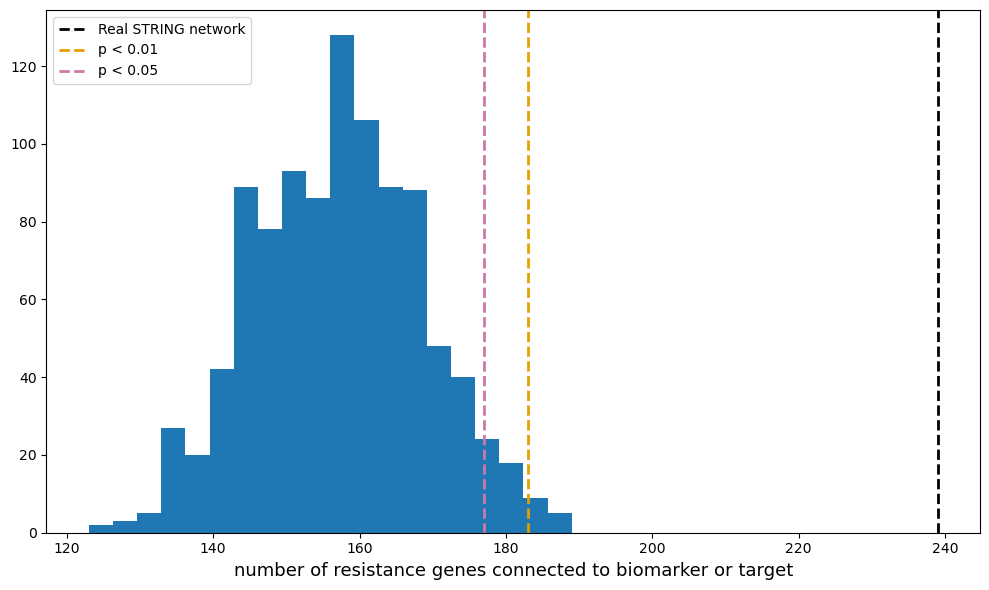

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Okabe–Ito colors WITHOUT blue, green, or red for dashed lines ---
OI_ORANGE = "#E69F00"      # p = 0.01
OI_VERMIL = "#D55E00"      # p = 0.001
OI_PURPLE = "#CC79A7"      # p = 0.05
OI_BLACK = "#000000"       # real network line

merged_df_string = pd.read_csv('results/4_randomness/all_pairs_merged_random_network_results_clean.csv')
df = merged_df_string.copy()

# --- 1. Random network columns ---
random_cols = [col for col in df.columns if col.startswith("Interaction_Random_")]

# --- 2. Resistant subset ---
res_df = df[df["Resistance"] == 1]

# --- 3. Compute random sums ---
random_sums = res_df[random_cols].sum(axis=0).values

# --- 4. Real network ---
real_network = res_df["Interaction_REAL"].sum()

# --- 5. Sorted random networks ---
sorted_desc = np.sort(random_sums)[::-1]

# p thresholds
val_10 = sorted_desc[9]  if len(sorted_desc) >= 10 else None   # p = 0.01
val_50 = sorted_desc[49] if len(sorted_desc) >= 50 else None   # p = 0.05

# --- 6. Plot ---
plt.figure(figsize=(10, 6))
plt.hist(random_sums, bins=20, edgecolor='black', linewidth=0)

plt.xlabel("number of resistance genes connected to biomarker or target", fontsize=13)

# Real network → black line
plt.axvline(real_network, color=OI_BLACK, linestyle='dashed', linewidth=2,
            label=f"Real STRING network")

# p = 0.01 → Orange
if val_10 is not None:
    plt.axvline(val_10, color=OI_ORANGE, linestyle='dashed', linewidth=2,
                label=f"p < 0.01")

# p = 0.05 → Purple
if val_50 is not None:
    plt.axvline(val_50, color=OI_PURPLE, linestyle='dashed', linewidth=2,
                label=f"p < 0.05")

plt.legend()
plt.tight_layout()
plt.savefig('results/4_randomness/random_networks_string_interaction_histogram_50_100_1_okabe.jpeg', dpi=600)
plt.show()


# BIOGRID

In [ ]:
import os
import numpy as np
import pandas as pd

def run_pair_triple_with_random_biogrid(
    protein_name_1,
    protein_name_2,
    pair_name,
    screen_prefix,
    random_folder='input_data/4_randomness/biogrid_random_networks',
    n_random=1000
):
    """
    For a given protein pair (by OFFICIAL GENE SYMBOL), compute interaction partners
    from the real BIOGRID network and n_random random BIOGRID-like networks.

    Adds:
        - Interaction_REAL
        - Interaction_Random_1 ... Interaction_Random_n

    to the screen file:
        input_data/2_output_with_hgnc/{screen_prefix}_{pair_name}_screen_with_hgnc.csv

    Matching is done using Ensembl IDs (screen['ensembl_gene_id']) derived via HGNC.
    """

    # === Load HGNC
    hgnc = pd.read_csv(
        'input_data/HGNC/hgnc_complete_set.txt',
        sep='\t'
    )
    columns_to_include = [
        'hgnc_id', 'symbol', 'prev_symbol', 'ensembl_gene_id', 'alias_symbol', 'entrez_id'
    ]
    hgnc_dict = hgnc[columns_to_include].to_dict(orient='records')

    # === Build HGNC lookup (same logic as your Biogrid script)
    def normalize_symbol(s):
        return s.strip().upper() if isinstance(s, str) else None

    gene_lookup = {}
    for entry in hgnc_dict:
        hgnc_id = entry.get('hgnc_id', np.nan)
        ensembl_id = entry.get('ensembl_gene_id', np.nan)
        entrez_id = str(entry.get('entrez_id', 'NA')) if pd.notnull(entry.get('entrez_id')) else 'NA'

        syms = []
        s = normalize_symbol(entry.get('symbol'))
        if s:
            syms.append(s)
        if pd.notnull(entry.get('prev_symbol')):
            syms.extend(normalize_symbol(x) for x in entry['prev_symbol'].split('|'))
        if pd.notnull(entry.get('alias_symbol')):
            syms.extend(normalize_symbol(x) for x in entry['alias_symbol'].split('|'))

        for sym in syms:
            if sym and sym not in gene_lookup:
                gene_lookup[sym] = (hgnc_id, ensembl_id, entrez_id)

    def lookup_gene_info(gene_symbol):
        key = normalize_symbol(gene_symbol)
        return gene_lookup.get(key, (np.nan, np.nan, 'NA'))

    # === Helper to get partners for protein_name_1 and protein_name_2
    def get_ppi_partners(biogrid_df):
        """
        biogrid_df must have columns:
            'Official Symbol Interactor A'
            'Official Symbol Interactor B'
        with human gene symbols.
        """

        p1_edges = biogrid_df[
            (biogrid_df['Official Symbol Interactor A'] == protein_name_1) |
            (biogrid_df['Official Symbol Interactor B'] == protein_name_1)
        ]
        p2_edges = biogrid_df[
            (biogrid_df['Official Symbol Interactor A'] == protein_name_2) |
            (biogrid_df['Official Symbol Interactor B'] == protein_name_2)
        ]

        ppi_partners = pd.concat([p1_edges, p2_edges], ignore_index=True)

        # Deduplicate undirected interactions
        ppi_partners['SortedInteractors'] = ppi_partners.apply(
            lambda row: '-'.join(
                np.sort([row['Official Symbol Interactor A'], row['Official Symbol Interactor B']])
            ),
            axis=1
        )
        ppi_partners = ppi_partners.drop_duplicates(subset='SortedInteractors').drop(
            columns='SortedInteractors'
        ).reset_index(drop=True)

        # Map to HGNC / Ensembl
        ppi_partners['hgnc_id_1'], ppi_partners['ensembl_gene_id_1'], ppi_partners['entrez_id_1'] = zip(
            *ppi_partners['Official Symbol Interactor A'].apply(lookup_gene_info)
        )
        ppi_partners['hgnc_id_2'], ppi_partners['ensembl_gene_id_2'], ppi_partners['entrez_id_2'] = zip(
            *ppi_partners['Official Symbol Interactor B'].apply(lookup_gene_info)
        )

        return ppi_partners

    # === Real BIOGRID network
    print("Processing real BIOGRID network...")
    biogrid_real = pd.read_csv(
        'input_data/BIOGRID/BIOGRID-MV-Physical-4.4.229.tab3.txt',
        sep='\t'
    )
    biogrid_real = biogrid_real[
        (biogrid_real['Organism Name Interactor A'] == 'Homo sapiens') &
        (biogrid_real['Organism Name Interactor B'] == 'Homo sapiens')
    ]

    real_partners = get_ppi_partners(biogrid_real)

    # === Load screen file
    screen_path = f'input_data/2_output_with_hgnc/{screen_prefix}_{pair_name}_screen_with_hgnc.csv'
    screen = pd.read_csv(screen_path)

    # Ensure Ensembl IDs are usable
    valid_ids = screen['ensembl_gene_id'].fillna("").astype(str).str.strip()

    # Real network interaction column
    screen['Interaction_REAL'] = (
        valid_ids.isin(real_partners['ensembl_gene_id_1']) |
        valid_ids.isin(real_partners['ensembl_gene_id_2'])
    ).astype(int)

    # === Loop over random BIOGRID-like networks
    random_cols = {}

    for i in range(1, n_random+1):
        print(f"  → Processing BIOGRID random network {i}...")

        # Adjust the naming pattern here if needed
        file_path = os.path.join(random_folder, f'biogrid_random_{i-1}.txt')
        if not os.path.exists(file_path):
            print(f"⚠️ Missing random file: {file_path}")
            continue

        # Random networks: option B (only gene symbols)
        biogrid_rand = pd.read_csv(
            file_path,
            sep='\t',
            header=None,
            names=['Official Symbol Interactor A', 'Official Symbol Interactor B']
        )

        rand_partners = get_ppi_partners(biogrid_rand)

        random_cols[f'Interaction_Random_{i}'] = (
            valid_ids.isin(rand_partners['ensembl_gene_id_1']) |
            valid_ids.isin(rand_partners['ensembl_gene_id_2'])
        ).astype(int)

    # === Combine all random network columns
    screen = pd.concat([screen, pd.DataFrame(random_cols)], axis=1)

    print("✅ All BIOGRID networks (real + random) processed successfully.")
    return screen


# === Example run
screen_out_biogrid = run_pair_triple_with_random_biogrid(
    protein_name_1="PTEN",
    protein_name_2="PIK3CB",
    pair_name="PTEN_PIK3CB",
    screen_prefix="dunn"
)

# Save result
screen_out_biogrid.to_csv(
    'results/4_randomness/PTEN_PIK3CB_random_network_biogrid_results_new_format.csv',
    index=False
)


/var/folders/cs/dzdz0ppx7lld40ztphtqg_dh0000gp/T/ipykernel_21981/1936007526.py:28: DtypeWarning: Columns (32,34,38,40,50) have mixed types. Specify dtype option on import or set low_memory=False.
  hgnc = pd.read_csv(


Processing real BIOGRID network...


/var/folders/cs/dzdz0ppx7lld40ztphtqg_dh0000gp/T/ipykernel_21981/1936007526.py:107: DtypeWarning: Columns (1,2) have mixed types. Specify dtype option on import or set low_memory=False.
  biogrid_real = pd.read_csv(


  → Processing BIOGRID random network 1...
  → Processing BIOGRID random network 2...
  → Processing BIOGRID random network 3...
  → Processing BIOGRID random network 4...
  → Processing BIOGRID random network 5...
  → Processing BIOGRID random network 6...
  → Processing BIOGRID random network 7...
  → Processing BIOGRID random network 8...
  → Processing BIOGRID random network 9...
  → Processing BIOGRID random network 10...
  → Processing BIOGRID random network 11...
  → Processing BIOGRID random network 12...
  → Processing BIOGRID random network 13...
  → Processing BIOGRID random network 14...
  → Processing BIOGRID random network 15...
  → Processing BIOGRID random network 16...
  → Processing BIOGRID random network 17...
  → Processing BIOGRID random network 18...
  → Processing BIOGRID random network 19...
  → Processing BIOGRID random network 20...
  → Processing BIOGRID random network 21...
  → Processing BIOGRID random network 22...
  → Processing BIOGRID random network 23.

In [ ]:
import os
import numpy as np
import pandas as pd

def run_pair_with_random_biogrid_multi(
    protein_1,
    protein_list_2,
    pair_name,
    screen_prefix,
    random_folder='input_data/4_randomness/biogrid_random_networks',
    n_random=1000
):
    """
    BIOGRID real + 1000 random network analysis,
    identical to PTEN–PIK3CB logic but supporting MULTIPLE proteins on side 2.

    Example:
        protein_1 = "PTEN"
        protein_list_2 = ["AKT1", "AKT2", "AKT3", "AKT4"]
    """

    # === Load HGNC ===
    hgnc = pd.read_csv(
        'input_data/HGNC/hgnc_complete_set.txt',
        sep='\t'
    )
    cols = ['hgnc_id','symbol','prev_symbol','ensembl_gene_id','alias_symbol','entrez_id']
    hgnc_dict = hgnc[cols].to_dict(orient='records')

    # === HGNC lookup ===
    def normalize_symbol(s):
        return s.strip().upper() if isinstance(s, str) else None

    gene_lookup = {}
    for entry in hgnc_dict:
        hgnc_id = entry['hgnc_id']
        ensembl = entry['ensembl_gene_id']
        entrez = str(entry['entrez_id']) if pd.notnull(entry['entrez_id']) else 'NA'

        syms = []

        main = normalize_symbol(entry['symbol'])
        if main:
            syms.append(main)

        if pd.notnull(entry['prev_symbol']):
            syms.extend(normalize_symbol(x) for x in entry['prev_symbol'].split('|'))

        if pd.notnull(entry['alias_symbol']):
            syms.extend(normalize_symbol(x) for x in entry['alias_symbol'].split('|'))

        for sym in syms:
            if sym not in gene_lookup:
                gene_lookup[sym] = (hgnc_id, ensembl, entrez)

    def lookup_gene(symbol):
        key = normalize_symbol(symbol)
        return gene_lookup.get(key, (np.nan, np.nan, 'NA'))

    # === Load REAL BIOGRID ===
    biogrid = pd.read_csv(
        'input_data/BIOGRID/BIOGRID-MV-Physical-4.4.229.tab3.txt',
        sep='\t'
    )
    biogrid = biogrid[
        (biogrid['Organism Name Interactor A'] == 'Homo sapiens') &
        (biogrid['Organism Name Interactor B'] == 'Homo sapiens')
    ]

    # === Collect all edges involving PTEN and any AKT paralog ===
    all_proteins = [protein_1] + protein_list_2

    edges_real = []
    for pname in all_proteins:
        sub = biogrid[
            (biogrid['Official Symbol Interactor A'] == pname) |
            (biogrid['Official Symbol Interactor B'] == pname)
        ]
        edges_real.append(sub)

    real_ppi = pd.concat(edges_real, ignore_index=True)

    # Deduplicate
    real_ppi['Sorted'] = real_ppi.apply(
        lambda row: '-'.join(np.sort([
            row['Official Symbol Interactor A'],
            row['Official Symbol Interactor B']
        ])),
        axis=1
    )
    real_ppi = real_ppi.drop_duplicates(subset='Sorted').drop(columns='Sorted')

    # Map to HGNC
    real_ppi['hgnc_id_1'], real_ppi['ensembl_1'], real_ppi['entrez_1'] = zip(
        *real_ppi['Official Symbol Interactor A'].apply(lookup_gene)
    )
    real_ppi['hgnc_id_2'], real_ppi['ensembl_2'], real_ppi['entrez_2'] = zip(
        *real_ppi['Official Symbol Interactor B'].apply(lookup_gene)
    )

    # === Load screen
    screen = pd.read_csv(
        f'input_data/2_output_with_hgnc/{screen_prefix}_{pair_name}_screen_with_hgnc.csv'
    )
    valid_ids = screen['ensembl_gene_id'].fillna("").astype(str)

    # === REAL interactions
    screen['Interaction_REAL'] = (
        valid_ids.isin(real_ppi['ensembl_1']) |
        valid_ids.isin(real_ppi['ensembl_2'])
    ).astype(int)

    # === RANDOM networks
    random_cols = {}

    for i in range(1, n_random + 1):
        print(f"→ Random network {i}")

        fp = os.path.join(random_folder, f'biogrid_random_{i-1}.txt')
        if not os.path.exists(fp):
            print("Missing:", fp)
            continue

        rand_df = pd.read_csv(
            fp, sep='\t', header=None,
            names=['Official Symbol Interactor A', 'Official Symbol Interactor B']
        )

        edges_rand = []
        for pname in all_proteins:
            sub = rand_df[
                (rand_df['Official Symbol Interactor A'] == pname) |
                (rand_df['Official Symbol Interactor B'] == pname)
            ]
            edges_rand.append(sub)

        rand_ppi = pd.concat(edges_rand, ignore_index=True)

        rand_ppi['Sorted'] = rand_ppi.apply(
            lambda row: '-'.join(np.sort([
                row['Official Symbol Interactor A'],
                row['Official Symbol Interactor B']
            ])),
            axis=1
        )
        rand_ppi = rand_ppi.drop_duplicates(subset='Sorted').drop(columns='Sorted')

        rand_ppi['hgnc_id_1'], rand_ppi['ensembl_1'], rand_ppi['entrez_1'] = zip(
            *rand_ppi['Official Symbol Interactor A'].apply(lookup_gene)
        )
        rand_ppi['hgnc_id_2'], rand_ppi['ensembl_2'], rand_ppi['entrez_2'] = zip(
            *rand_ppi['Official Symbol Interactor B'].apply(lookup_gene)
        )

        random_cols[f'Interaction_Random_{i}'] = (
            valid_ids.isin(rand_ppi['ensembl_1']) |
            valid_ids.isin(rand_ppi['ensembl_2'])
        ).astype(int)

    screen = pd.concat([screen, pd.DataFrame(random_cols)], axis=1)

    print("✓ PTEN–AKT random BIOGRID pipeline complete.")
    return screen
screen_out = run_pair_with_random_biogrid_multi(
    protein_1="PTEN",
    protein_list_2=["AKT1", "AKT2", "AKT3", "AKT4"],
    pair_name="PTEN_AKT",
    screen_prefix="dunn"
)

screen_out.to_csv(
    'results/4_randomness/PTEN_AKT_random_network_biogrid_results_new_format.csv',
    index=False
)


/var/folders/cs/dzdz0ppx7lld40ztphtqg_dh0000gp/T/ipykernel_21981/1479067344.py:23: DtypeWarning: Columns (32,34,38,40,50) have mixed types. Specify dtype option on import or set low_memory=False.
  hgnc = pd.read_csv(
/var/folders/cs/dzdz0ppx7lld40ztphtqg_dh0000gp/T/ipykernel_21981/1479067344.py:61: DtypeWarning: Columns (1,2) have mixed types. Specify dtype option on import or set low_memory=False.
  biogrid = pd.read_csv(


→ Random network 1
→ Random network 2
→ Random network 3
→ Random network 4
→ Random network 5
→ Random network 6
→ Random network 7
→ Random network 8
→ Random network 9
→ Random network 10
→ Random network 11
→ Random network 12
→ Random network 13
→ Random network 14
→ Random network 15
→ Random network 16
→ Random network 17
→ Random network 18
→ Random network 19
→ Random network 20
→ Random network 21
→ Random network 22
→ Random network 23
→ Random network 24
→ Random network 25
→ Random network 26
→ Random network 27
→ Random network 28
→ Random network 29
→ Random network 30
→ Random network 31
→ Random network 32
→ Random network 33
→ Random network 34
→ Random network 35
→ Random network 36
→ Random network 37
→ Random network 38
→ Random network 39
→ Random network 40
→ Random network 41
→ Random network 42
→ Random network 43
→ Random network 44
→ Random network 45
→ Random network 46
→ Random network 47
→ Random network 48
→ Random network 49
→ Random network 50
→ Random 

In [ ]:
import os
import numpy as np
import pandas as pd

def run_pair_two_gene_with_random_biogrid(
    protein_name_1,
    protein_name_2,
    pair_name,
    screen_prefix,
    random_folder='input_data/4_randomness/biogrid_random_networks',
    n_random=1000
):
    """
    BIOGRID version of run_pair_triple_with_random for TWO proteins.
    Equivalent to PTEN-PIK3CB STRING pipeline, but:
      - uses Biogrid real PPI
      - uses Biogrid random networks
      - uses two proteins (ATR, ARID1A)
      - screen file: {pair_name}_{screen_prefix}_aggregated.csv
    """

    # === Load HGNC ===
    hgnc = pd.read_csv(
        'input_data/HGNC/hgnc_complete_set.txt',
        sep='\t'
    )
    keep = ['hgnc_id','symbol','prev_symbol','ensembl_gene_id','alias_symbol','entrez_id']
    hgnc_dict = hgnc[keep].to_dict(orient='records')

    # === HGNC lookup ===
    def normalize_symbol(s):
        return s.strip().upper() if isinstance(s, str) else None

    gene_lookup = {}
    for entry in hgnc_dict:
        hgnc_id = entry['hgnc_id']
        ensembl = entry['ensembl_gene_id']
        entrez = str(entry['entrez_id']) if pd.notnull(entry['entrez_id']) else 'NA'

        syms = []

        main = normalize_symbol(entry['symbol'])
        if main:
            syms.append(main)
        if pd.notnull(entry['prev_symbol']):
            syms.extend(normalize_symbol(x) for x in entry['prev_symbol'].split('|'))
        if pd.notnull(entry['alias_symbol']):
            syms.extend(normalize_symbol(x) for x in entry['alias_symbol'].split('|'))

        for sym in syms:
            if sym not in gene_lookup:
                gene_lookup[sym] = (hgnc_id, ensembl, entrez)

    def lookup_gene(symbol):
        key = normalize_symbol(symbol)
        return gene_lookup.get(key, (np.nan, np.nan, 'NA'))

    # === Load REAL BIOGRID ===
    biogrid = pd.read_csv(
        'input_data/BIOGRID/BIOGRID-MV-Physical-4.4.229.tab3.txt',
        sep='\t'
    )
    biogrid = biogrid[
        (biogrid['Organism Name Interactor A'] == 'Homo sapiens') &
        (biogrid['Organism Name Interactor B'] == 'Homo sapiens')
    ]

    # === Collect real ATR–ARID1A edges ===
    p1_edges = biogrid[
        (biogrid['Official Symbol Interactor A'] == protein_name_1) |
        (biogrid['Official Symbol Interactor B'] == protein_name_1)
    ]
    p2_edges = biogrid[
        (biogrid['Official Symbol Interactor A'] == protein_name_2) |
        (biogrid['Official Symbol Interactor B'] == protein_name_2)
    ]

    real_ppi = pd.concat([p1_edges, p2_edges], ignore_index=True)

    # Deduplicate
    real_ppi['Sorted'] = real_ppi.apply(
        lambda row: '-'.join(np.sort([
            row['Official Symbol Interactor A'],
            row['Official Symbol Interactor B']
        ])),
        axis=1
    )
    real_ppi = real_ppi.drop_duplicates(subset='Sorted').drop(columns='Sorted')

    # HGNC mapping
    real_ppi['hgnc_id_1'], real_ppi['ensembl_1'], real_ppi['entrez_1'] = zip(
        *real_ppi['Official Symbol Interactor A'].apply(lookup_gene)
    )
    real_ppi['hgnc_id_2'], real_ppi['ensembl_2'], real_ppi['entrez_2'] = zip(
        *real_ppi['Official Symbol Interactor B'].apply(lookup_gene)
    )

    # === Load screen ===
    screen = pd.read_csv(
        f'input_data/2_output_with_hgnc/{pair_name}_{screen_prefix}_aggregated.csv'
    )
    valid_ids = screen['ensembl_gene_id'].fillna("").astype(str)

    # === REAL interaction ===
    screen['Interaction_REAL'] = (
        valid_ids.isin(real_ppi['ensembl_1']) |
        valid_ids.isin(real_ppi['ensembl_2'])
    ).astype(int)

    # === RANDOM networks ===
    random_cols = {}

    for i in range(1, n_random + 1):
        print(f"→ Random network {i}")

        fp = os.path.join(random_folder, f'biogrid_random_{i-1}.txt')
        if not os.path.exists(fp):
            print("Missing:", fp)
            continue

        rand_df = pd.read_csv(
            fp, sep='\t', header=None,
            names=['Official Symbol Interactor A', 'Official Symbol Interactor B']
        )

        # Random edges for both genes
        r1 = rand_df[
            (rand_df['Official Symbol Interactor A'] == protein_name_1) |
            (rand_df['Official Symbol Interactor B'] == protein_name_1)
        ]
        r2 = rand_df[
            (rand_df['Official Symbol Interactor A'] == protein_name_2) |
            (rand_df['Official Symbol Interactor B'] == protein_name_2)
        ]

        rand_ppi = pd.concat([r1, r2], ignore_index=True)

        # Deduplicate
        rand_ppi['Sorted'] = rand_ppi.apply(
            lambda row: '-'.join(np.sort([
                row['Official Symbol Interactor A'],
                row['Official Symbol Interactor B']
            ])),
            axis=1
        )
        rand_ppi = rand_ppi.drop_duplicates(subset='Sorted').drop(columns='Sorted')

        # HGNC mapping
        rand_ppi['hgnc_id_1'], rand_ppi['ensembl_1'], rand_ppi['entrez_1'] = zip(
            *rand_ppi['Official Symbol Interactor A'].apply(lookup_gene)
        )
        rand_ppi['hgnc_id_2'], rand_ppi['ensembl_2'], rand_ppi['entrez_2'] = zip(
            *rand_ppi['Official Symbol Interactor B'].apply(lookup_gene)
        )

        # Add random flag
        random_cols[f'Interaction_Random_{i}'] = (
            valid_ids.isin(rand_ppi['ensembl_1']) |
            valid_ids.isin(rand_ppi['ensembl_2'])
        ).astype(int)

    # Combine
    screen = pd.concat([screen, pd.DataFrame(random_cols)], axis=1)

    print("✓ BIOGRID random ATR–ARID1A pipeline complete.")
    return screen
screen_out = run_pair_two_gene_with_random_biogrid(
    protein_name_1="ATR",
    protein_name_2="ARID1A",
    pair_name="ARID1A_ATR",
    screen_prefix="Awwad_Llorca"
)

screen_out.to_csv(
    'results/4_randomness/ARID1A_ATR_random_network_biogrid_results_new_format.csv',
    index=False
)


/var/folders/cs/dzdz0ppx7lld40ztphtqg_dh0000gp/T/ipykernel_21981/2744099851.py:23: DtypeWarning: Columns (32,34,38,40,50) have mixed types. Specify dtype option on import or set low_memory=False.
  hgnc = pd.read_csv(
/var/folders/cs/dzdz0ppx7lld40ztphtqg_dh0000gp/T/ipykernel_21981/2744099851.py:59: DtypeWarning: Columns (1,2) have mixed types. Specify dtype option on import or set low_memory=False.
  biogrid = pd.read_csv(


→ Random network 1
→ Random network 2
→ Random network 3
→ Random network 4
→ Random network 5
→ Random network 6
→ Random network 7
→ Random network 8
→ Random network 9
→ Random network 10
→ Random network 11
→ Random network 12
→ Random network 13
→ Random network 14
→ Random network 15
→ Random network 16
→ Random network 17
→ Random network 18
→ Random network 19
→ Random network 20
→ Random network 21
→ Random network 22
→ Random network 23
→ Random network 24
→ Random network 25
→ Random network 26
→ Random network 27
→ Random network 28
→ Random network 29
→ Random network 30
→ Random network 31
→ Random network 32
→ Random network 33
→ Random network 34
→ Random network 35
→ Random network 36
→ Random network 37
→ Random network 38
→ Random network 39
→ Random network 40
→ Random network 41
→ Random network 42
→ Random network 43
→ Random network 44
→ Random network 45
→ Random network 46
→ Random network 47
→ Random network 48
→ Random network 49
→ Random network 50
→ Random 

In [ ]:
import os
import numpy as np
import pandas as pd

def run_pair_five_gene_with_random_biogrid(
    protein_name_1,
    protein_name_2,
    protein_name_3,
    protein_name_4,
    protein_name_5,
    pair_name,
    screen_prefix,
    random_folder='input_data/4_randomness/biogrid_random_networks',
    n_random=1000
):
    """
    BIOGRID 5-protein version of the STRING random-network pipeline.
    Equivalent to KRAS–MEK STRING version, but using:
        - Biogrid real interactions
        - Biogrid random networks (symbol–symbol)
        - 5 gene names (KRAS + MAP2K1/MEK1 + MAP2K2/MEK2)
    """

    # === Load HGNC ===
    hgnc = pd.read_csv(
        'input_data/HGNC/hgnc_complete_set.txt',
        sep='\t'
    )
    cols = ['hgnc_id','symbol','prev_symbol','ensembl_gene_id','alias_symbol','entrez_id']
    hgnc_dict = hgnc[cols].to_dict(orient='records')

    # === HGNC lookup ===
    def normalize_symbol(s):
        return s.strip().upper() if isinstance(s, str) else None

    gene_lookup = {}
    for entry in hgnc_dict:
        hgnc_id = entry['hgnc_id']
        ensemb = entry['ensembl_gene_id']
        entrez = str(entry['entrez_id']) if pd.notnull(entry['entrez_id']) else 'NA'

        symlist = []

        main = normalize_symbol(entry['symbol'])
        if main:
            symlist.append(main)
        if pd.notnull(entry['prev_symbol']):
            symlist.extend(normalize_symbol(x) for x in entry['prev_symbol'].split('|'))
        if pd.notnull(entry['alias_symbol']):
            symlist.extend(normalize_symbol(x) for x in entry['alias_symbol'].split('|'))

        for s in symlist:
            if s not in gene_lookup:
                gene_lookup[s] = (hgnc_id, ensemb, entrez)

    def lookup_gene(sym):
        key = normalize_symbol(sym)
        return gene_lookup.get(key, (np.nan, np.nan, 'NA'))

    # === Load REAL BIOGRID ===
    biogrid = pd.read_csv(
        'input_data/BIOGRID/BIOGRID-MV-Physical-4.4.229.tab3.txt',
        sep='\t'
    )

    biogrid = biogrid[
        (biogrid['Organism Name Interactor A'] == 'Homo sapiens') &
        (biogrid['Organism Name Interactor B'] == 'Homo sapiens')
    ]

    # === Get REAL KRAS–MEK edges (5 symbols) ===
    targets = [protein_name_1, protein_name_2, protein_name_3, protein_name_4, protein_name_5]

    def get_edges_for_symbol(symbol):
        return biogrid[
            (biogrid['Official Symbol Interactor A'] == symbol) |
            (biogrid['Official Symbol Interactor B'] == symbol)
        ]

    all_edges = pd.concat([get_edges_for_symbol(x) for x in targets], ignore_index=True)

    # Deduplicate
    all_edges['Sorted'] = all_edges.apply(
        lambda row: '-'.join(np.sort([
            row['Official Symbol Interactor A'],
            row['Official Symbol Interactor B']
        ])),
        axis=1
    )
    all_edges = all_edges.drop_duplicates(subset='Sorted').drop(columns='Sorted')

    # HGNC mapping
    all_edges['hgnc_id_1'], all_edges['ensembl_1'], all_edges['entrez_1'] = zip(
        *all_edges['Official Symbol Interactor A'].apply(lookup_gene)
    )
    all_edges['hgnc_id_2'], all_edges['ensembl_2'], all_edges['entrez_2'] = zip(
        *all_edges['Official Symbol Interactor B'].apply(lookup_gene)
    )

    # === Load and annotate screen ===
    screen = pd.read_csv(
        f'input_data/2_output_with_hgnc/{pair_name}_{screen_prefix}_aggregated.csv'
    )

    valid_ids = screen['ensembl_gene_id'].fillna("").astype(str)

    # REAL interactions
    screen['Interaction_REAL'] = (
        valid_ids.isin(all_edges['ensembl_1']) |
        valid_ids.isin(all_edges['ensembl_2'])
    ).astype(int)

    # === Random networks ===
    random_cols = {}

    for i in range(1, n_random + 1):
        print(f"→ Processing Biogrid random {i}")

        fp = os.path.join(random_folder, f'biogrid_random_{i-1}.txt')
        if not os.path.exists(fp):
            print("Missing:", fp)
            continue

        rand_df = pd.read_csv(
            fp, sep='\t', header=None,
            names=['Official Symbol Interactor A','Official Symbol Interactor B']
        )

        # Collect partner edges for each MEK variant + KRAS
        r_edges = []
        for symbol in targets:
            r_edges.append(
                rand_df[
                    (rand_df['Official Symbol Interactor A'] == symbol) |
                    (rand_df['Official Symbol Interactor B'] == symbol)
                ]
            )

        rand_edges = pd.concat(r_edges, ignore_index=True)

        # Deduplicate
        rand_edges['Sorted'] = rand_edges.apply(
            lambda row: '-'.join(np.sort([
                row['Official Symbol Interactor A'],
                row['Official Symbol Interactor B']
            ])),
            axis=1
        )
        rand_edges = rand_edges.drop_duplicates(subset='Sorted').drop(columns='Sorted')

        # HGNC map
        rand_edges['hgnc_id_1'], rand_edges['ensembl_1'], rand_edges['entrez_1'] = zip(
            *rand_edges['Official Symbol Interactor A'].apply(lookup_gene)
        )
        rand_edges['hgnc_id_2'], rand_edges['ensembl_2'], rand_edges['entrez_2'] = zip(
            *rand_edges['Official Symbol Interactor B'].apply(lookup_gene)
        )

        random_cols[f'Interaction_Random_{i}'] = (
            valid_ids.isin(rand_edges['ensembl_1']) |
            valid_ids.isin(rand_edges['ensembl_2'])
        ).astype(int)

    # Add to screen
    screen = pd.concat([screen, pd.DataFrame(random_cols)], axis=1)

    print("✓ KRAS–MEK BIOGRID random pipeline complete.")
    return screen
screen_out = run_pair_five_gene_with_random_biogrid(
    protein_name_1="KRAS",
    protein_name_2="MAP2K1",
    protein_name_3="MEK1",
    protein_name_4="MAP2K2",
    protein_name_5="MEK2",
    pair_name="KRAS_MEK",
    screen_prefix="Krall_Wang_Yu"
)

screen_out.to_csv(
    'results/4_randomness/KRAS_MEK_random_network_biogrid_results_new_format.csv',
    index=False
)


/var/folders/cs/dzdz0ppx7lld40ztphtqg_dh0000gp/T/ipykernel_21981/63491824.py:25: DtypeWarning: Columns (32,34,38,40,50) have mixed types. Specify dtype option on import or set low_memory=False.
  hgnc = pd.read_csv(
/var/folders/cs/dzdz0ppx7lld40ztphtqg_dh0000gp/T/ipykernel_21981/63491824.py:61: DtypeWarning: Columns (1,2) have mixed types. Specify dtype option on import or set low_memory=False.
  biogrid = pd.read_csv(


→ Processing Biogrid random 1
→ Processing Biogrid random 2
→ Processing Biogrid random 3
→ Processing Biogrid random 4
→ Processing Biogrid random 5
→ Processing Biogrid random 6
→ Processing Biogrid random 7
→ Processing Biogrid random 8
→ Processing Biogrid random 9
→ Processing Biogrid random 10
→ Processing Biogrid random 11
→ Processing Biogrid random 12
→ Processing Biogrid random 13
→ Processing Biogrid random 14
→ Processing Biogrid random 15
→ Processing Biogrid random 16
→ Processing Biogrid random 17
→ Processing Biogrid random 18
→ Processing Biogrid random 19
→ Processing Biogrid random 20
→ Processing Biogrid random 21
→ Processing Biogrid random 22
→ Processing Biogrid random 23
→ Processing Biogrid random 24
→ Processing Biogrid random 25
→ Processing Biogrid random 26
→ Processing Biogrid random 27
→ Processing Biogrid random 28
→ Processing Biogrid random 29
→ Processing Biogrid random 30
→ Processing Biogrid random 31
→ Processing Biogrid random 32
→ Processing Biog

In [ ]:
import os
import numpy as np
import pandas as pd

def run_pair_two_gene_with_random_biogrid(
    protein_name_1,
    protein_name_2,
    pair_name,
    screen_prefix,
    random_folder='input_data/4_randomness/biogrid_random_networks',
    n_random=1000
):
    """
    BIOGRID random-network pipeline for two-gene pairs (BRCA1–PARP1 style).
    Structure matches STRING random pipeline:
        - Real Biogrid PPI interactions
        - Random Biogrid PPI interactions
        - Outputs Interaction_REAL + Interaction_Random_i
    """

    # === Load HGNC ===
    hgnc = pd.read_csv(
        'input_data/HGNC/hgnc_complete_set.txt',
        sep='\t'
    )
    keep = ['hgnc_id','symbol','prev_symbol','ensembl_gene_id','alias_symbol','entrez_id']
    hgnc_dict = hgnc[keep].to_dict(orient='records')

    # === HGNC lookup ===
    def normalize_symbol(s):
        return s.strip().upper() if isinstance(s, str) else None

    gene_lookup = {}
    for entry in hgnc_dict:
        hgnc_id = entry['hgnc_id']
        ensembl = entry['ensembl_gene_id']
        entrez = str(entry['entrez_id']) if pd.notnull(entry['entrez_id']) else 'NA'

        syms = []

        main = normalize_symbol(entry['symbol'])
        if main:
            syms.append(main)

        if pd.notnull(entry['prev_symbol']):
            syms.extend(normalize_symbol(x) for x in entry['prev_symbol'].split('|'))

        if pd.notnull(entry['alias_symbol']):
            syms.extend(normalize_symbol(x) for x in entry['alias_symbol'].split('|'))

        for s in syms:
            if s not in gene_lookup:
                gene_lookup[s] = (hgnc_id, ensembl, entrez)

    def lookup_gene(symbol):
        key = normalize_symbol(symbol)
        return gene_lookup.get(key, (np.nan, np.nan, 'NA'))

    # === Load REAL BIOGRID ===
    biogrid = pd.read_csv(
        'input_data/BIOGRID/BIOGRID-MV-Physical-4.4.229.tab3.txt',
        sep='\t'
    )

    biogrid = biogrid[
        (biogrid['Organism Name Interactor A'] == 'Homo sapiens') &
        (biogrid['Organism Name Interactor B'] == 'Homo sapiens')
    ]

    # === Extract real edges for BRCA1 + PARP1 ===
    def get_edges_for_symbol(sym):
        return biogrid[
            (biogrid['Official Symbol Interactor A'] == sym) |
            (biogrid['Official Symbol Interactor B'] == sym)
        ]

    real_edges = pd.concat([
        get_edges_for_symbol(protein_name_1),
        get_edges_for_symbol(protein_name_2)
    ], ignore_index=True)

    # Deduplicate edges
    real_edges['Sorted'] = real_edges.apply(
        lambda row: '-'.join(np.sort([
            row['Official Symbol Interactor A'],
            row['Official Symbol Interactor B']
        ])),
        axis=1
    )
    real_edges = real_edges.drop_duplicates(subset='Sorted').drop(columns='Sorted')

    # HGNC mapping
    real_edges['hgnc_id_1'], real_edges['ensembl_1'], real_edges['entrez_1'] = zip(
        *real_edges['Official Symbol Interactor A'].apply(lookup_gene)
    )
    real_edges['hgnc_id_2'], real_edges['ensembl_2'], real_edges['entrez_2'] = zip(
        *real_edges['Official Symbol Interactor B'].apply(lookup_gene)
    )

    # === Load screen ===
    screen = pd.read_csv(
        f'input_data/2_output_with_hgnc/{pair_name}_{screen_prefix}_aggregated.csv'
    )

    valid_ids = screen['ensembl_gene_id'].fillna("").astype(str)

    # === Real interactions ===
    screen['Interaction_REAL'] = (
        valid_ids.isin(real_edges['ensembl_1']) |
        valid_ids.isin(real_edges['ensembl_2'])
    ).astype(int)

    # === RANDOM NETWORKS ===
    random_cols = {}

    print("Processing Biogrid random networks...")

    for i in range(1, n_random + 1):
        fp = os.path.join(random_folder, f'biogrid_random_{i-1}.txt')

        print(f" → Random {i}")

        if not os.path.exists(fp):
            print("Missing:", fp)
            continue

        rand_df = pd.read_csv(
            fp, sep='\t', header=None,
            names=['Official Symbol Interactor A','Official Symbol Interactor B']
        )

        # Collect BRCA1 + PARP1 edges
        r1 = rand_df[
            (rand_df['Official Symbol Interactor A'] == protein_name_1) |
            (rand_df['Official Symbol Interactor B'] == protein_name_1)
        ]
        r2 = rand_df[
            (rand_df['Official Symbol Interactor A'] == protein_name_2) |
            (rand_df['Official Symbol Interactor B'] == protein_name_2)
        ]

        rand_edges = pd.concat([r1, r2], ignore_index=True)

        # Deduplicate
        rand_edges['Sorted'] = rand_edges.apply(
            lambda row: '-'.join(np.sort([
                row['Official Symbol Interactor A'],
                row['Official Symbol Interactor B']
            ])),
            axis=1
        )
        rand_edges = rand_edges.drop_duplicates(subset='Sorted').drop(columns='Sorted')

        # HGNC mapping
        rand_edges['hgnc_id_1'], rand_edges['ensembl_1'], rand_edges['entrez_1'] = zip(
            *rand_edges['Official Symbol Interactor A'].apply(lookup_gene)
        )
        rand_edges['hgnc_id_2'], rand_edges['ensembl_2'], rand_edges['entrez_2'] = zip(
            *rand_edges['Official Symbol Interactor B'].apply(lookup_gene)
        )

        # Add interaction column
        random_cols[f'Interaction_Random_{i}'] = (
            valid_ids.isin(rand_edges['ensembl_1']) |
            valid_ids.isin(rand_edges['ensembl_2'])
        ).astype(int)

    # Add random network results
    screen = pd.concat([screen, pd.DataFrame(random_cols)], axis=1)

    print("✓ BRCA1–PARP1 Biogrid random pipeline complete.")
    return screen
screen_out = run_pair_two_gene_with_random_biogrid(
    protein_name_1="BRCA1",
    protein_name_2="PARP1",
    pair_name="BRCA1_PARP1",
    screen_prefix="Noordermeer_Zimmermann"
)

screen_out.to_csv(
    'results/4_randomness/BRCA1_PARP_random_network_biogrid_results_new_format.csv',
    index=False
)


/var/folders/cs/dzdz0ppx7lld40ztphtqg_dh0000gp/T/ipykernel_21981/1294076268.py:22: DtypeWarning: Columns (32,34,38,40,50) have mixed types. Specify dtype option on import or set low_memory=False.
  hgnc = pd.read_csv(
/var/folders/cs/dzdz0ppx7lld40ztphtqg_dh0000gp/T/ipykernel_21981/1294076268.py:60: DtypeWarning: Columns (1,2) have mixed types. Specify dtype option on import or set low_memory=False.
  biogrid = pd.read_csv(


Processing Biogrid random networks...
 → Random 1
 → Random 2
 → Random 3
 → Random 4
 → Random 5
 → Random 6
 → Random 7
 → Random 8
 → Random 9
 → Random 10
 → Random 11
 → Random 12
 → Random 13
 → Random 14
 → Random 15
 → Random 16
 → Random 17
 → Random 18
 → Random 19
 → Random 20
 → Random 21
 → Random 22
 → Random 23
 → Random 24
 → Random 25
 → Random 26
 → Random 27
 → Random 28
 → Random 29
 → Random 30
 → Random 31
 → Random 32
 → Random 33
 → Random 34
 → Random 35
 → Random 36
 → Random 37
 → Random 38
 → Random 39
 → Random 40
 → Random 41
 → Random 42
 → Random 43
 → Random 44
 → Random 45
 → Random 46
 → Random 47
 → Random 48
 → Random 49
 → Random 50
 → Random 51
 → Random 52
 → Random 53
 → Random 54
 → Random 55
 → Random 56
 → Random 57
 → Random 58
 → Random 59
 → Random 60
 → Random 61
 → Random 62
 → Random 63
 → Random 64
 → Random 65
 → Random 66
 → Random 67
 → Random 68
 → Random 69
 → Random 70
 → Random 71
 → Random 72
 → Random 73
 → Random 74
 → Random

In [ ]:
import os
import numpy as np
import pandas as pd

def run_pair_five_gene_with_random_biogrid(
    protein_name_1,
    protein_name_2,
    protein_name_3,
    protein_name_4,
    protein_name_5,
    pair_name,
    screen_prefix,
    random_folder='input_data/4_randomness/biogrid_random_networks',
    n_random=1000
):
    """
    BIOGRID 5-protein version of the STRING random-network pipeline.
    Equivalent to KRAS–MEK STRING version, but using:
        - Biogrid real interactions
        - Biogrid random networks (symbol–symbol)
        - 5 gene names (KRAS + MAP2K1/MEK1 + MAP2K2/MEK2)
    """

    # === Load HGNC ===
    hgnc = pd.read_csv(
        'input_data/HGNC/hgnc_complete_set.txt',
        sep='\t'
    )
    cols = ['hgnc_id','symbol','prev_symbol','ensembl_gene_id','alias_symbol','entrez_id']
    hgnc_dict = hgnc[cols].to_dict(orient='records')

    # === HGNC lookup ===
    def normalize_symbol(s):
        return s.strip().upper() if isinstance(s, str) else None

    gene_lookup = {}
    for entry in hgnc_dict:
        hgnc_id = entry['hgnc_id']
        ensemb = entry['ensembl_gene_id']
        entrez = str(entry['entrez_id']) if pd.notnull(entry['entrez_id']) else 'NA'

        symlist = []

        main = normalize_symbol(entry['symbol'])
        if main:
            symlist.append(main)
        if pd.notnull(entry['prev_symbol']):
            symlist.extend(normalize_symbol(x) for x in entry['prev_symbol'].split('|'))
        if pd.notnull(entry['alias_symbol']):
            symlist.extend(normalize_symbol(x) for x in entry['alias_symbol'].split('|'))

        for s in symlist:
            if s not in gene_lookup:
                gene_lookup[s] = (hgnc_id, ensemb, entrez)

    def lookup_gene(sym):
        key = normalize_symbol(sym)
        return gene_lookup.get(key, (np.nan, np.nan, 'NA'))

    # === Load REAL BIOGRID ===
    biogrid = pd.read_csv(
        'input_data/BIOGRID/BIOGRID-MV-Physical-4.4.229.tab3.txt',
        sep='\t'
    )

    biogrid = biogrid[
        (biogrid['Organism Name Interactor A'] == 'Homo sapiens') &
        (biogrid['Organism Name Interactor B'] == 'Homo sapiens')
    ]

    # === Get REAL KRAS–MEK edges (5 symbols) ===
    targets = [protein_name_1, protein_name_2, protein_name_3, protein_name_4, protein_name_5]

    def get_edges_for_symbol(symbol):
        return biogrid[
            (biogrid['Official Symbol Interactor A'] == symbol) |
            (biogrid['Official Symbol Interactor B'] == symbol)
        ]

    all_edges = pd.concat([get_edges_for_symbol(x) for x in targets], ignore_index=True)

    # Deduplicate
    all_edges['Sorted'] = all_edges.apply(
        lambda row: '-'.join(np.sort([
            row['Official Symbol Interactor A'],
            row['Official Symbol Interactor B']
        ])),
        axis=1
    )
    all_edges = all_edges.drop_duplicates(subset='Sorted').drop(columns='Sorted')

    # HGNC mapping
    all_edges['hgnc_id_1'], all_edges['ensembl_1'], all_edges['entrez_1'] = zip(
        *all_edges['Official Symbol Interactor A'].apply(lookup_gene)
    )
    all_edges['hgnc_id_2'], all_edges['ensembl_2'], all_edges['entrez_2'] = zip(
        *all_edges['Official Symbol Interactor B'].apply(lookup_gene)
    )

    # === Load and annotate screen ===
    screen = pd.read_csv(
        f'input_data/2_output_with_hgnc/{pair_name}_{screen_prefix}_aggregated.csv'
    )

    valid_ids = screen['ensembl_gene_id'].fillna("").astype(str)

    # REAL interactions
    screen['Interaction_REAL'] = (
        valid_ids.isin(all_edges['ensembl_1']) |
        valid_ids.isin(all_edges['ensembl_2'])
    ).astype(int)

    # === Random networks ===
    random_cols = {}

    for i in range(1, n_random + 1):
        print(f"→ Processing Biogrid random {i}")

        fp = os.path.join(random_folder, f'biogrid_random_{i-1}.txt')
        if not os.path.exists(fp):
            print("Missing:", fp)
            continue

        rand_df = pd.read_csv(
            fp, sep='\t', header=None,
            names=['Official Symbol Interactor A','Official Symbol Interactor B']
        )

        # Collect partner edges for each MEK variant + KRAS
        r_edges = []
        for symbol in targets:
            r_edges.append(
                rand_df[
                    (rand_df['Official Symbol Interactor A'] == symbol) |
                    (rand_df['Official Symbol Interactor B'] == symbol)
                ]
            )

        rand_edges = pd.concat(r_edges, ignore_index=True)

        # Deduplicate
        rand_edges['Sorted'] = rand_edges.apply(
            lambda row: '-'.join(np.sort([
                row['Official Symbol Interactor A'],
                row['Official Symbol Interactor B']
            ])),
            axis=1
        )
        rand_edges = rand_edges.drop_duplicates(subset='Sorted').drop(columns='Sorted')

        # HGNC map
        rand_edges['hgnc_id_1'], rand_edges['ensembl_1'], rand_edges['entrez_1'] = zip(
            *rand_edges['Official Symbol Interactor A'].apply(lookup_gene)
        )
        rand_edges['hgnc_id_2'], rand_edges['ensembl_2'], rand_edges['entrez_2'] = zip(
            *rand_edges['Official Symbol Interactor B'].apply(lookup_gene)
        )

        random_cols[f'Interaction_Random_{i}'] = (
            valid_ids.isin(rand_edges['ensembl_1']) |
            valid_ids.isin(rand_edges['ensembl_2'])
        ).astype(int)

    # Add to screen
    screen = pd.concat([screen, pd.DataFrame(random_cols)], axis=1)

    print("✓ NRAS–MEK BIOGRID random pipeline complete.")
    return screen
screen_out = run_pair_five_gene_with_random_biogrid(
    protein_name_1="NRAS",
    protein_name_2="MAP2K1",
    protein_name_3="MEK1",
    protein_name_4="MAP2K2",
    protein_name_5="MEK2",
    pair_name="NRAS_MEK",
    screen_prefix="Hayes_Krall"
)

screen_out.to_csv(
    'results/4_randomness/NRAS_MEK_random_network_biogrid_results_new_format.csv',
    index=False
)


/var/folders/cs/dzdz0ppx7lld40ztphtqg_dh0000gp/T/ipykernel_21981/1616376761.py:25: DtypeWarning: Columns (32,34,38,40,50) have mixed types. Specify dtype option on import or set low_memory=False.
  hgnc = pd.read_csv(
/var/folders/cs/dzdz0ppx7lld40ztphtqg_dh0000gp/T/ipykernel_21981/1616376761.py:61: DtypeWarning: Columns (1,2) have mixed types. Specify dtype option on import or set low_memory=False.
  biogrid = pd.read_csv(


→ Processing Biogrid random 1
→ Processing Biogrid random 2
→ Processing Biogrid random 3
→ Processing Biogrid random 4
→ Processing Biogrid random 5
→ Processing Biogrid random 6
→ Processing Biogrid random 7
→ Processing Biogrid random 8
→ Processing Biogrid random 9
→ Processing Biogrid random 10
→ Processing Biogrid random 11
→ Processing Biogrid random 12
→ Processing Biogrid random 13
→ Processing Biogrid random 14
→ Processing Biogrid random 15
→ Processing Biogrid random 16
→ Processing Biogrid random 17
→ Processing Biogrid random 18
→ Processing Biogrid random 19
→ Processing Biogrid random 20
→ Processing Biogrid random 21
→ Processing Biogrid random 22
→ Processing Biogrid random 23
→ Processing Biogrid random 24
→ Processing Biogrid random 25
→ Processing Biogrid random 26
→ Processing Biogrid random 27
→ Processing Biogrid random 28
→ Processing Biogrid random 29
→ Processing Biogrid random 30
→ Processing Biogrid random 31
→ Processing Biogrid random 32
→ Processing Biog

In [ ]:
import os
import numpy as np
import pandas as pd

def run_pair_five_gene_with_random_biogrid(
    protein_name_1,
    protein_name_2,
    protein_name_3,
    protein_name_4,
    protein_name_5,
    pair_name,
    screen_prefix,
    random_folder='input_data/4_randomness/biogrid_random_networks',
    n_random=1000
):
    """
    BIOGRID 5-protein version of the STRING random-network pipeline.
    Equivalent to KRAS–MEK STRING version, but using:
        - Biogrid real interactions
        - Biogrid random networks (symbol–symbol)
        - 5 gene names (KRAS + MAP2K1/MEK1 + MAP2K2/MEK2)
    """

    # === Load HGNC ===
    hgnc = pd.read_csv(
        'input_data/HGNC/hgnc_complete_set.txt',
        sep='\t'
    )
    cols = ['hgnc_id','symbol','prev_symbol','ensembl_gene_id','alias_symbol','entrez_id']
    hgnc_dict = hgnc[cols].to_dict(orient='records')

    # === HGNC lookup ===
    def normalize_symbol(s):
        return s.strip().upper() if isinstance(s, str) else None

    gene_lookup = {}
    for entry in hgnc_dict:
        hgnc_id = entry['hgnc_id']
        ensemb = entry['ensembl_gene_id']
        entrez = str(entry['entrez_id']) if pd.notnull(entry['entrez_id']) else 'NA'

        symlist = []

        main = normalize_symbol(entry['symbol'])
        if main:
            symlist.append(main)
        if pd.notnull(entry['prev_symbol']):
            symlist.extend(normalize_symbol(x) for x in entry['prev_symbol'].split('|'))
        if pd.notnull(entry['alias_symbol']):
            symlist.extend(normalize_symbol(x) for x in entry['alias_symbol'].split('|'))

        for s in symlist:
            if s not in gene_lookup:
                gene_lookup[s] = (hgnc_id, ensemb, entrez)

    def lookup_gene(sym):
        key = normalize_symbol(sym)
        return gene_lookup.get(key, (np.nan, np.nan, 'NA'))

    # === Load REAL BIOGRID ===
    biogrid = pd.read_csv(
        'input_data/BIOGRID/BIOGRID-MV-Physical-4.4.229.tab3.txt',
        sep='\t'
    )

    biogrid = biogrid[
        (biogrid['Organism Name Interactor A'] == 'Homo sapiens') &
        (biogrid['Organism Name Interactor B'] == 'Homo sapiens')
    ]

    # === Get REAL KRAS–MEK edges (5 symbols) ===
    targets = [protein_name_1, protein_name_2, protein_name_3, protein_name_4, protein_name_5]

    def get_edges_for_symbol(symbol):
        return biogrid[
            (biogrid['Official Symbol Interactor A'] == symbol) |
            (biogrid['Official Symbol Interactor B'] == symbol)
        ]

    all_edges = pd.concat([get_edges_for_symbol(x) for x in targets], ignore_index=True)

    # Deduplicate
    all_edges['Sorted'] = all_edges.apply(
        lambda row: '-'.join(np.sort([
            row['Official Symbol Interactor A'],
            row['Official Symbol Interactor B']
        ])),
        axis=1
    )
    all_edges = all_edges.drop_duplicates(subset='Sorted').drop(columns='Sorted')

    # HGNC mapping
    all_edges['hgnc_id_1'], all_edges['ensembl_1'], all_edges['entrez_1'] = zip(
        *all_edges['Official Symbol Interactor A'].apply(lookup_gene)
    )
    all_edges['hgnc_id_2'], all_edges['ensembl_2'], all_edges['entrez_2'] = zip(
        *all_edges['Official Symbol Interactor B'].apply(lookup_gene)
    )

    # === Load and annotate screen ===
    screen = pd.read_csv(f'input_data/2_output_with_hgnc/{screen_prefix}_{pair_name}_screen_with_hgnc.csv')


    valid_ids = screen['ensembl_gene_id'].fillna("").astype(str)

    # REAL interactions
    screen['Interaction_REAL'] = (
        valid_ids.isin(all_edges['ensembl_1']) |
        valid_ids.isin(all_edges['ensembl_2'])
    ).astype(int)

    # === Random networks ===
    random_cols = {}

    for i in range(1, n_random + 1):
        print(f"→ Processing Biogrid random {i}")

        fp = os.path.join(random_folder, f'biogrid_random_{i-1}.txt')
        if not os.path.exists(fp):
            print("Missing:", fp)
            continue

        rand_df = pd.read_csv(
            fp, sep='\t', header=None,
            names=['Official Symbol Interactor A','Official Symbol Interactor B']
        )

        # Collect partner edges for each MEK variant + KRAS
        r_edges = []
        for symbol in targets:
            r_edges.append(
                rand_df[
                    (rand_df['Official Symbol Interactor A'] == symbol) |
                    (rand_df['Official Symbol Interactor B'] == symbol)
                ]
            )

        rand_edges = pd.concat(r_edges, ignore_index=True)

        # Deduplicate
        rand_edges['Sorted'] = rand_edges.apply(
            lambda row: '-'.join(np.sort([
                row['Official Symbol Interactor A'],
                row['Official Symbol Interactor B']
            ])),
            axis=1
        )
        rand_edges = rand_edges.drop_duplicates(subset='Sorted').drop(columns='Sorted')

        # HGNC map
        rand_edges['hgnc_id_1'], rand_edges['ensembl_1'], rand_edges['entrez_1'] = zip(
            *rand_edges['Official Symbol Interactor A'].apply(lookup_gene)
        )
        rand_edges['hgnc_id_2'], rand_edges['ensembl_2'], rand_edges['entrez_2'] = zip(
            *rand_edges['Official Symbol Interactor B'].apply(lookup_gene)
        )

        random_cols[f'Interaction_Random_{i}'] = (
            valid_ids.isin(rand_edges['ensembl_1']) |
            valid_ids.isin(rand_edges['ensembl_2'])
        ).astype(int)

    # Add to screen
    screen = pd.concat([screen, pd.DataFrame(random_cols)], axis=1)

    print("✓ NRAS–CDK4-6 BIOGRID random pipeline complete.")
    return screen
screen_out = run_pair_five_gene_with_random_biogrid(
    protein_name_1 = "NRAS",   
    protein_name_2="CDK4",   
    protein_name_3="Cdk4",   
    protein_name_4="CDK6", 
    protein_name_5="Cdk6",  
    pair_name="NRAS_CDK4_6",          # used in filenames
    screen_prefix="hayes" 
)

screen_out.to_csv(
    'results/4_randomness/NRAS_CDK4_6_random_network_biogrid_results_new_format.csv',
    index=False
)


/var/folders/cs/dzdz0ppx7lld40ztphtqg_dh0000gp/T/ipykernel_21981/2393576395.py:25: DtypeWarning: Columns (32,34,38,40,50) have mixed types. Specify dtype option on import or set low_memory=False.
  hgnc = pd.read_csv(
/var/folders/cs/dzdz0ppx7lld40ztphtqg_dh0000gp/T/ipykernel_21981/2393576395.py:61: DtypeWarning: Columns (1,2) have mixed types. Specify dtype option on import or set low_memory=False.
  biogrid = pd.read_csv(


→ Processing Biogrid random 1
→ Processing Biogrid random 2
→ Processing Biogrid random 3
→ Processing Biogrid random 4
→ Processing Biogrid random 5
→ Processing Biogrid random 6
→ Processing Biogrid random 7
→ Processing Biogrid random 8
→ Processing Biogrid random 9
→ Processing Biogrid random 10
→ Processing Biogrid random 11
→ Processing Biogrid random 12
→ Processing Biogrid random 13
→ Processing Biogrid random 14
→ Processing Biogrid random 15
→ Processing Biogrid random 16
→ Processing Biogrid random 17
→ Processing Biogrid random 18
→ Processing Biogrid random 19
→ Processing Biogrid random 20
→ Processing Biogrid random 21
→ Processing Biogrid random 22
→ Processing Biogrid random 23
→ Processing Biogrid random 24
→ Processing Biogrid random 25
→ Processing Biogrid random 26
→ Processing Biogrid random 27
→ Processing Biogrid random 28
→ Processing Biogrid random 29
→ Processing Biogrid random 30
→ Processing Biogrid random 31
→ Processing Biogrid random 32
→ Processing Biog

In [ ]:
import os
import numpy as np
import pandas as pd

def run_pair_five_gene_with_random_biogrid(
    protein_name_1,
    protein_name_2,
    protein_name_3,
    protein_name_4,
    protein_name_5,
    pair_name,
    screen_prefix,
    random_folder='input_data/4_randomness/biogrid_random_networks',
    n_random=1000
):
    """
    BIOGRID 5-protein version of the STRING random-network pipeline.
    Equivalent to KRAS–MEK STRING version, but using:
        - Biogrid real interactions
        - Biogrid random networks (symbol–symbol)
        - 5 gene names (KRAS + MAP2K1/MEK1 + MAP2K2/MEK2)
    """

    # === Load HGNC ===
    hgnc = pd.read_csv(
        'input_data/HGNC/hgnc_complete_set.txt',
        sep='\t'
    )
    cols = ['hgnc_id','symbol','prev_symbol','ensembl_gene_id','alias_symbol','entrez_id']
    hgnc_dict = hgnc[cols].to_dict(orient='records')

    # === HGNC lookup ===
    def normalize_symbol(s):
        return s.strip().upper() if isinstance(s, str) else None

    gene_lookup = {}
    for entry in hgnc_dict:
        hgnc_id = entry['hgnc_id']
        ensemb = entry['ensembl_gene_id']
        entrez = str(entry['entrez_id']) if pd.notnull(entry['entrez_id']) else 'NA'

        symlist = []

        main = normalize_symbol(entry['symbol'])
        if main:
            symlist.append(main)
        if pd.notnull(entry['prev_symbol']):
            symlist.extend(normalize_symbol(x) for x in entry['prev_symbol'].split('|'))
        if pd.notnull(entry['alias_symbol']):
            symlist.extend(normalize_symbol(x) for x in entry['alias_symbol'].split('|'))

        for s in symlist:
            if s not in gene_lookup:
                gene_lookup[s] = (hgnc_id, ensemb, entrez)

    def lookup_gene(sym):
        key = normalize_symbol(sym)
        return gene_lookup.get(key, (np.nan, np.nan, 'NA'))

    # === Load REAL BIOGRID ===
    biogrid = pd.read_csv(
        'input_data/BIOGRID/BIOGRID-MV-Physical-4.4.229.tab3.txt',
        sep='\t'
    )

    biogrid = biogrid[
        (biogrid['Organism Name Interactor A'] == 'Homo sapiens') &
        (biogrid['Organism Name Interactor B'] == 'Homo sapiens')
    ]

    # === Get REAL KRAS–MEK edges (5 symbols) ===
    targets = [protein_name_1, protein_name_2, protein_name_3, protein_name_4, protein_name_5]

    def get_edges_for_symbol(symbol):
        return biogrid[
            (biogrid['Official Symbol Interactor A'] == symbol) |
            (biogrid['Official Symbol Interactor B'] == symbol)
        ]

    all_edges = pd.concat([get_edges_for_symbol(x) for x in targets], ignore_index=True)

    # Deduplicate
    all_edges['Sorted'] = all_edges.apply(
        lambda row: '-'.join(np.sort([
            row['Official Symbol Interactor A'],
            row['Official Symbol Interactor B']
        ])),
        axis=1
    )
    all_edges = all_edges.drop_duplicates(subset='Sorted').drop(columns='Sorted')

    # HGNC mapping
    all_edges['hgnc_id_1'], all_edges['ensembl_1'], all_edges['entrez_1'] = zip(
        *all_edges['Official Symbol Interactor A'].apply(lookup_gene)
    )
    all_edges['hgnc_id_2'], all_edges['ensembl_2'], all_edges['entrez_2'] = zip(
        *all_edges['Official Symbol Interactor B'].apply(lookup_gene)
    )

    # === Load and annotate screen ===
    screen = pd.read_csv(f'input_data/2_output_with_hgnc/{screen_prefix}_{pair_name}_screen_with_hgnc.csv')


    valid_ids = screen['ensembl_gene_id'].fillna("").astype(str)

    # REAL interactions
    screen['Interaction_REAL'] = (
        valid_ids.isin(all_edges['ensembl_1']) |
        valid_ids.isin(all_edges['ensembl_2'])
    ).astype(int)

    # === Random networks ===
    random_cols = {}

    for i in range(1, n_random + 1):
        print(f"→ Processing Biogrid random {i}")

        fp = os.path.join(random_folder, f'biogrid_random_{i-1}.txt')
        if not os.path.exists(fp):
            print("Missing:", fp)
            continue

        rand_df = pd.read_csv(
            fp, sep='\t', header=None,
            names=['Official Symbol Interactor A','Official Symbol Interactor B']
        )

        # Collect partner edges for each MEK variant + KRAS
        r_edges = []
        for symbol in targets:
            r_edges.append(
                rand_df[
                    (rand_df['Official Symbol Interactor A'] == symbol) |
                    (rand_df['Official Symbol Interactor B'] == symbol)
                ]
            )

        rand_edges = pd.concat(r_edges, ignore_index=True)

        # Deduplicate
        rand_edges['Sorted'] = rand_edges.apply(
            lambda row: '-'.join(np.sort([
                row['Official Symbol Interactor A'],
                row['Official Symbol Interactor B']
            ])),
            axis=1
        )
        rand_edges = rand_edges.drop_duplicates(subset='Sorted').drop(columns='Sorted')

        # HGNC map
        rand_edges['hgnc_id_1'], rand_edges['ensembl_1'], rand_edges['entrez_1'] = zip(
            *rand_edges['Official Symbol Interactor A'].apply(lookup_gene)
        )
        rand_edges['hgnc_id_2'], rand_edges['ensembl_2'], rand_edges['entrez_2'] = zip(
            *rand_edges['Official Symbol Interactor B'].apply(lookup_gene)
        )

        random_cols[f'Interaction_Random_{i}'] = (
            valid_ids.isin(rand_edges['ensembl_1']) |
            valid_ids.isin(rand_edges['ensembl_2'])
        ).astype(int)

    # Add to screen
    screen = pd.concat([screen, pd.DataFrame(random_cols)], axis=1)

    print("✓ BRAF–MEK BIOGRID random pipeline complete.")
    return screen
screen_out = run_pair_five_gene_with_random_biogrid(
    protein_name_1 = "BRAF",   # BRAF
    protein_name_2="MAP2K1",   # MAP2K1
    protein_name_3="MEK1",   # MEK1
    protein_name_4="MAP2K2"  , # MAP2K2
    protein_name_5="MEK2",  # MEK2
    pair_name="BRAF_MEK",          # used in filenames
    screen_prefix="krall"              # which screen to load
)

screen_out.to_csv(
    'results/4_randomness/BRAF_MEK_random_network_biogrid_results_new_format.csv',
    index=False
)


/var/folders/cs/dzdz0ppx7lld40ztphtqg_dh0000gp/T/ipykernel_21981/1823598499.py:25: DtypeWarning: Columns (32,34,38,40,50) have mixed types. Specify dtype option on import or set low_memory=False.
  hgnc = pd.read_csv(
/var/folders/cs/dzdz0ppx7lld40ztphtqg_dh0000gp/T/ipykernel_21981/1823598499.py:61: DtypeWarning: Columns (1,2) have mixed types. Specify dtype option on import or set low_memory=False.
  biogrid = pd.read_csv(


→ Processing Biogrid random 1
→ Processing Biogrid random 2
→ Processing Biogrid random 3
→ Processing Biogrid random 4
→ Processing Biogrid random 5
→ Processing Biogrid random 6
→ Processing Biogrid random 7
→ Processing Biogrid random 8
→ Processing Biogrid random 9
→ Processing Biogrid random 10
→ Processing Biogrid random 11
→ Processing Biogrid random 12
→ Processing Biogrid random 13
→ Processing Biogrid random 14
→ Processing Biogrid random 15
→ Processing Biogrid random 16
→ Processing Biogrid random 17
→ Processing Biogrid random 18
→ Processing Biogrid random 19
→ Processing Biogrid random 20
→ Processing Biogrid random 21
→ Processing Biogrid random 22
→ Processing Biogrid random 23
→ Processing Biogrid random 24
→ Processing Biogrid random 25
→ Processing Biogrid random 26
→ Processing Biogrid random 27
→ Processing Biogrid random 28
→ Processing Biogrid random 29
→ Processing Biogrid random 30
→ Processing Biogrid random 31
→ Processing Biogrid random 32
→ Processing Biog

In [ ]:
import os
import pandas as pd
from glob import glob

# === Folder containing your files
folder = 'results/4_randomness'

# === Find all matching CSV files
file_list = sorted(glob(os.path.join(folder, '*_random_network_biogrid_results_new_format.csv')))
print(f"Found {len(file_list)} files to merge.\n")

merged_list = []

# === Loop through each file
for file_path in file_list:
    df = pd.read_csv(file_path)
    base_name = os.path.basename(file_path)

    # Extract pair name and split into biomarker / target
    pair_name = base_name.replace('_random_network_biogrid_results_new_format.csv', '')
    try:
        biomarker, target = pair_name.split('_', 1)
    except ValueError:
        biomarker, target = pair_name, None

    # Add metadata columns
    df['Pair_Name'] = pair_name
    df['Biomarker'] = biomarker
    df['Target'] = target

    # === Clean Resistance values
    if 'Resistance' in df.columns:
        # Step 1: unify naming
        df['Resistance'] = df['Resistance'].replace({'Not_Resistant': 'NotResistant'})
        # Step 2: map text → numeric
        df['Resistance'] = df['Resistance'].map({'NotResistant': 0, 'Resistant': 1})

    # === Rename "Gene" → "Query" if present
    if 'Gene' in df.columns:
        df = df.rename(columns={'Gene': 'Query'})

    # === Drop unwanted ID columns if they exist
    drop_cols = ['hgnc_id', 'ensembl_gene_id', 'entrez_id']
    df = df.drop(columns=[col for col in drop_cols if col in df.columns], errors='ignore')

    # === Reorder columns
    col_order_start = ['Query', 'Biomarker', 'Target', 'Resistance']
    remaining_cols = [c for c in df.columns if c not in col_order_start]
    df = df[col_order_start + remaining_cols]

    merged_list.append(df)
    print(f"✅ Loaded {pair_name}: {len(df)} rows | Biomarker: {biomarker}, Target: {target}")

# === Merge all dataframes
merged_df = pd.concat(merged_list, ignore_index=True)

# === Save merged dataframe
output_path = os.path.join(folder, 'all_pairs_merged_random_network_results_clean_biogrid.csv')
merged_df.to_csv(output_path, index=False)

print("\n🎉 Successfully merged and cleaned all files!")
print(f"→ Output saved to: {output_path}")
print(f"→ Total rows combined: {len(merged_df)}")
print(f"→ Total files merged: {len(file_list)}")


Found 8 files to merge.

✅ Loaded ARID1A_ATR: 18839 rows | Biomarker: ARID1A, Target: ATR


/var/folders/cs/dzdz0ppx7lld40ztphtqg_dh0000gp/T/ipykernel_21981/836548758.py:16: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


✅ Loaded BRAF_MEK: 18899 rows | Biomarker: BRAF, Target: MEK
✅ Loaded BRCA1_PARP: 17003 rows | Biomarker: BRCA1, Target: PARP
✅ Loaded KRAS_MEK: 18572 rows | Biomarker: KRAS, Target: MEK


/var/folders/cs/dzdz0ppx7lld40ztphtqg_dh0000gp/T/ipykernel_21981/836548758.py:16: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


✅ Loaded NRAS_CDK4_6: 16147 rows | Biomarker: NRAS, Target: CDK4_6
✅ Loaded NRAS_MEK: 18598 rows | Biomarker: NRAS, Target: MEK


/var/folders/cs/dzdz0ppx7lld40ztphtqg_dh0000gp/T/ipykernel_21981/836548758.py:16: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


✅ Loaded PTEN_AKT: 18012 rows | Biomarker: PTEN, Target: AKT


/var/folders/cs/dzdz0ppx7lld40ztphtqg_dh0000gp/T/ipykernel_21981/836548758.py:16: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


✅ Loaded PTEN_PIK3CB: 18010 rows | Biomarker: PTEN, Target: PIK3CB

🎉 Successfully merged and cleaned all files!
→ Output saved to: /Users/metinyazar/Desktop/drug_resistance_ppi/new_analysis_after_new_agg_21082025/results/5_randomness/all_pairs_merged_random_network_results_clean_biogrid.csv
→ Total rows combined: 144080
→ Total files merged: 8


/var/folders/cs/dzdz0ppx7lld40ztphtqg_dh0000gp/T/ipykernel_31007/1432926338.py:11: DtypeWarning: Columns (1007) have mixed types. Specify dtype option on import or set low_memory=False.
  merged_df_biogrid = pd.read_csv('results/4_randomness/all_pairs_merged_random_network_results_clean_biogrid.csv')


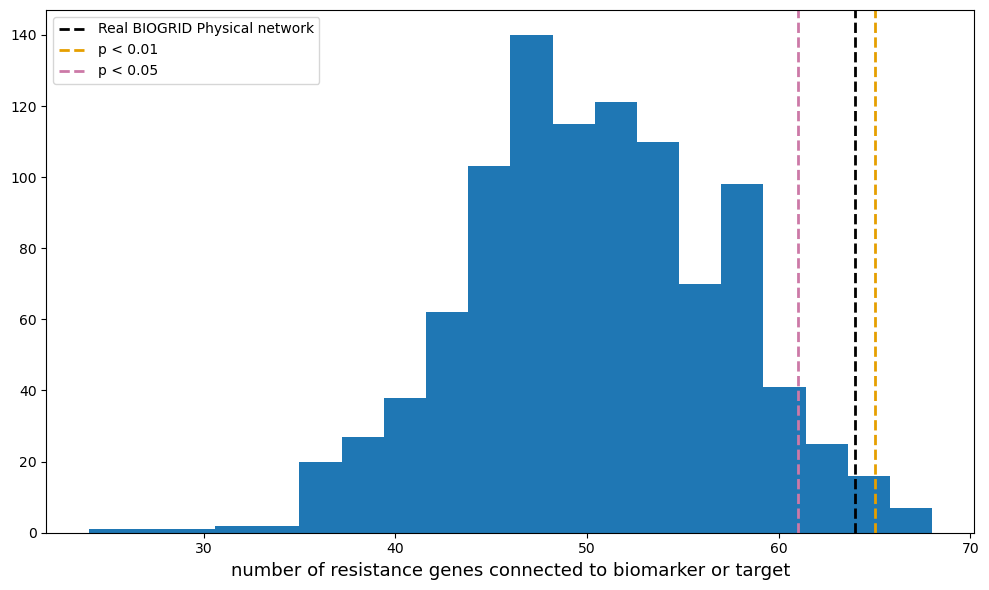

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Okabe–Ito colors WITHOUT blue, green, or red for dashed lines ---
OI_ORANGE = "#E69F00"      # p = 0.01
OI_VERMIL = "#D55E00"      # p = 0.001
OI_PURPLE = "#CC79A7"      # p = 0.05
OI_BLACK = "#000000"       # real network line

merged_df_biogrid = pd.read_csv('results/4_randomness/all_pairs_merged_random_network_results_clean_biogrid.csv')
df = merged_df_biogrid.copy()

# --- 1. Random network columns ---
random_cols = [col for col in df.columns if col.startswith("Interaction_Random_")]

# --- 2. Resistant subset ---
res_df = df[df["Resistance"] == 1]

# --- 3. Compute random sums ---
random_sums = res_df[random_cols].sum(axis=0).values

# --- 4. Real network ---
real_network = res_df["Interaction_REAL"].sum()

# --- 5. Sorted random networks ---
sorted_desc = np.sort(random_sums)[::-1]

# p thresholds
val_10 = sorted_desc[9]  if len(sorted_desc) >= 10 else None   # p = 0.01
val_50 = sorted_desc[49] if len(sorted_desc) >= 50 else None   # p = 0.05

# --- 6. Plot ---
plt.figure(figsize=(10, 6))
plt.hist(random_sums, bins=20, edgecolor='black', linewidth=0)

plt.xlabel("number of resistance genes connected to biomarker or target", fontsize=13)

# Real network → black line
plt.axvline(real_network, color=OI_BLACK, linestyle='dashed', linewidth=2,
            label=f"Real BIOGRID Physical network")

# p = 0.01 → Orange
if val_10 is not None:
    plt.axvline(val_10, color=OI_ORANGE, linestyle='dashed', linewidth=2,
                label=f"p < 0.01")

# p = 0.05 → Purple
if val_50 is not None:
    plt.axvline(val_50, color=OI_PURPLE, linestyle='dashed', linewidth=2,
                label=f"p < 0.05")

plt.legend()
plt.tight_layout()
plt.savefig('results/4_randomness/random_networks_biogrid_interaction_histogram_50_100_1_okabe.jpeg', dpi=600)
plt.show()
